# LOAD LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from diive.core.io.files import save_parquet, load_parquet
from datetime import datetime
import os
import sys
import shap
# Custom utilities
# Add the parent directory (project root) to sys.path
# "Go up two levels" and add to path
sys.path.append(os.path.abspath('../../../')) 
from src.config import PERIOD_START, PERIOD_END, select_period
from src.gapfilling_utils import (
    fit_gapfill_ts,
    build_df_for_parcel,
    apply_gapfill_ts,
    plot_gapfill_dashboard,
    merge_gapfill_results
)

# CONFIGURATION

In [2]:
START_DATE, END_DATE = PERIOD_START, PERIOD_END  # dataset period, see src/config.py
TARGET_FLUX = 'NEE'
RAND_ERR_COL = "FC_RANDUNC_HF"  # EddyPro random uncertainty col
MODEL_TYPE = 'XGBoost'  # Options: 'RandomForest' or 'XGBoost'
PARCEL_CERTAIN = True
LOG_TRANSFORM = False
UNDERSAMPLE = False
ADD_TRT = True
SHAP_CHECK = True

# LOAD DATA

In [3]:
data_main = fluxes = load_parquet(filepath=r"81.1.1_GapFillingDataset.parquet")
data_main = select_period(data_main, timestamp='middle')

# Make a copy of the original data for later use
maindf = data_main.copy()

# Keep only data where we are sure about parcel attribution
if PARCEL_CERTAIN:
    data_main = data_main[data_main['parcel_certainty'] == 'certain'].copy()
    print('\nKeeping only data when we are highly confident on the parcel attribution')
else:
    print('\nKeeping also data from mixed parcel contribution')

data_main

Loaded .parquet file 81.1.1_GapFillingDataset.parquet (0.782 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
select_period: kept 14928 of 14928 records (2023-10-17 00:15:00 to 2024-08-22 23:45:00, timestamp=middle)

Keeping only data when we are highly confident on the parcel attribution


,NEE_L3.3_CUT_16_QCF,NEE_L3.3_CUT_50_QCF,NEE_L3.3_CUT_84_QCF,NEE_L3.3_CUT_16_QCF0,NEE_L3.3_CUT_50_QCF0,NEE_L3.3_CUT_84_QCF0,parcel,parcel_certainty,trt,FC_RANDUNC_HF,SW_IN_POT,prec,ta,ppfd,sw_in,...,wfps_0.15_gfXG_diff12h,wfps_0.15_gfXG_diff24h,wfps_0.3_gfXG_diff6h,wfps_0.3_gfXG_diff12h,wfps_0.3_gfXG_diff24h,n_decay_linear,n_decay_logistic,n_decay_exponential,n_decay_lognormal,n_decay_timed,timesince_fert,timesince_fert_min,timesince_fert_org,can_height,id
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-11-07 15:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,NaN,267.16400,0.0,7.366667,135.496834,65.666667,...,0.186416,0.031227,0.385963,0.705085,0.129544,0.000000,0.000000,2.280252,1.041116,29.0,22.0,30.0,22.0,0.188254,1039
2023-11-07 16:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,NaN,168.35800,0.0,7.300000,54.832354,27.333333,...,0.179404,0.022161,0.321719,0.557017,0.072530,0.000000,0.000000,2.274546,1.037818,29.0,22.0,30.0,22.0,0.188641,1040
2023-11-07 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,NaN,3.38364,0.5,6.600000,0.000000,0.000000,...,-0.081217,0.029544,0.798931,0.793294,0.894488,0.000000,0.000000,2.263177,1.031258,29.0,22.0,30.0,22.0,0.189415,1042
2023-11-07 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,NaN,0.00000,0.2,6.633333,0.000000,0.000000,...,0.200712,0.435220,0.764205,0.910265,0.877980,0.000000,0.000000,2.257514,1.027996,29.0,22.0,30.0,22.0,0.189803,1043
2023-11-07 18:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,NaN,0.00000,0.5,6.366667,0.000000,0.000000,...,0.131912,0.327660,0.897999,1.085670,1.031942,0.000000,0.000000,2.251865,1.024747,29.0,22.0,30.0,22.0,0.190191,1044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,2.48319,0.00000,0.0,15.870000,0.000000,0.000000,...,-0.926389,-1.456268,-0.031887,-0.371716,-0.464268,184.456349,187.286349,174.585550,12.443672,188.0,1.0,30.0,1.0,0.000000,14923
2024-08-22 22:15:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,1.96792,0.00000,0.0,15.160000,0.000000,0.000000,...,-0.895817,-1.399429,-0.000719,-0.361714,-0.454507,184.269841,187.279204,173.906660,14.317380,188.0,1.0,30.0,1.0,0.000000,14924
2024-08-22 22:45:00,NaN,NaN,NaN,NaN,NaN,NaN,B,certain,1.0,3.14515,0.00000,0.0,15.100000,0.000000,0.000000,...,-0.886399,-1.435013,0.009201,-0.350463,-0.453738,184.083333,187.271988,173.230410,16.309472,188.0,1.0,30.0,1.0,0.000000,14925


# SELECT FEATURES

In [4]:
# Import the best features
path = 'best_features_' + TARGET_FLUX + '_' + MODEL_TYPE + '.txt'
with open(path, 'r') as f:
    selected_features = [line.strip() for line in f]

# Other option is to define the best n features
# n_top = 23
# path = 'ranked_features_' + TARGET_FLUX + '_' + DAY_NIGHT + '_' + MODEL_TYPE + '.txt'
# with open(path, 'r') as f:
#     selected_features = [line.strip() for line in f][:n_top]

# Remove specific variables if you want
#to_remove = ('flux_nee', 'prec')
#selected_features = [c for c in selected_features if not c.startswith(to_remove)]

# selected_features = [
#     'SW_IN_POT',
#     'ppfd',
#     'timesince_soil_preparation',
#     'timesince_sowing',
#     'n_decay_timed',
#     'ts_0.3_gfXG_roll3hmean'
# ]

# If ADD_TRT is True we add the trt variable even if it was not in the best feature set
if ADD_TRT:
    if 'trt' not in selected_features:
        selected_features.append('trt')
    print('\nThe treatment variable (trt) is included in the feature set')
else:
    if 'trt' in selected_features:
        selected_features.remove('trt')
    print('\nThe treatment variable (trt) is not included in the feature set')


The treatment variable (trt) is included in the feature set


# SELECT MODEL

In [5]:
# Load hyperparameters from JSON file
path = 'best_hyperparameters_' + TARGET_FLUX + '_' + MODEL_TYPE + '.json'
with open(path, "r") as file:
    hyperparams = json.load(file)

# Print loaded hyperparameters (optional)
print("Loaded Hyperparameters:", hyperparams)

def model_factory():
    if MODEL_TYPE == "RandomForest":
        return RandomForestRegressor(**hyperparams, random_state=42, n_jobs=-1)
    else:
        return XGBRegressor(**hyperparams, random_state=42, n_jobs=-1)

Loaded Hyperparameters: {'colsample_bytree': 0.9844762255295657, 'gamma': 0.45267532097803187, 'learning_rate': 0.024579113478929646, 'max_depth': 14, 'min_child_weight': 2, 'n_estimators': 352, 'subsample': 0.6377771843023713}


# GAP-FILLING

## CUT-16

In [6]:
USTAR_CUT = 'CUT_16'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_16_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...


  Gap distribution: fitted mixture (cvm distance 0.7838; raw baseline 13.5045)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.101
  Coverage: 755/6085 rows never held out (12.4%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_16_QCF0
  RMSE:   1.9197
  MAE:    1.1423
  R2:     0.9711
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 0.6340; raw baseline 13.1015)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 821/7004 rows never held out (11.7%); mean times held out 2.01


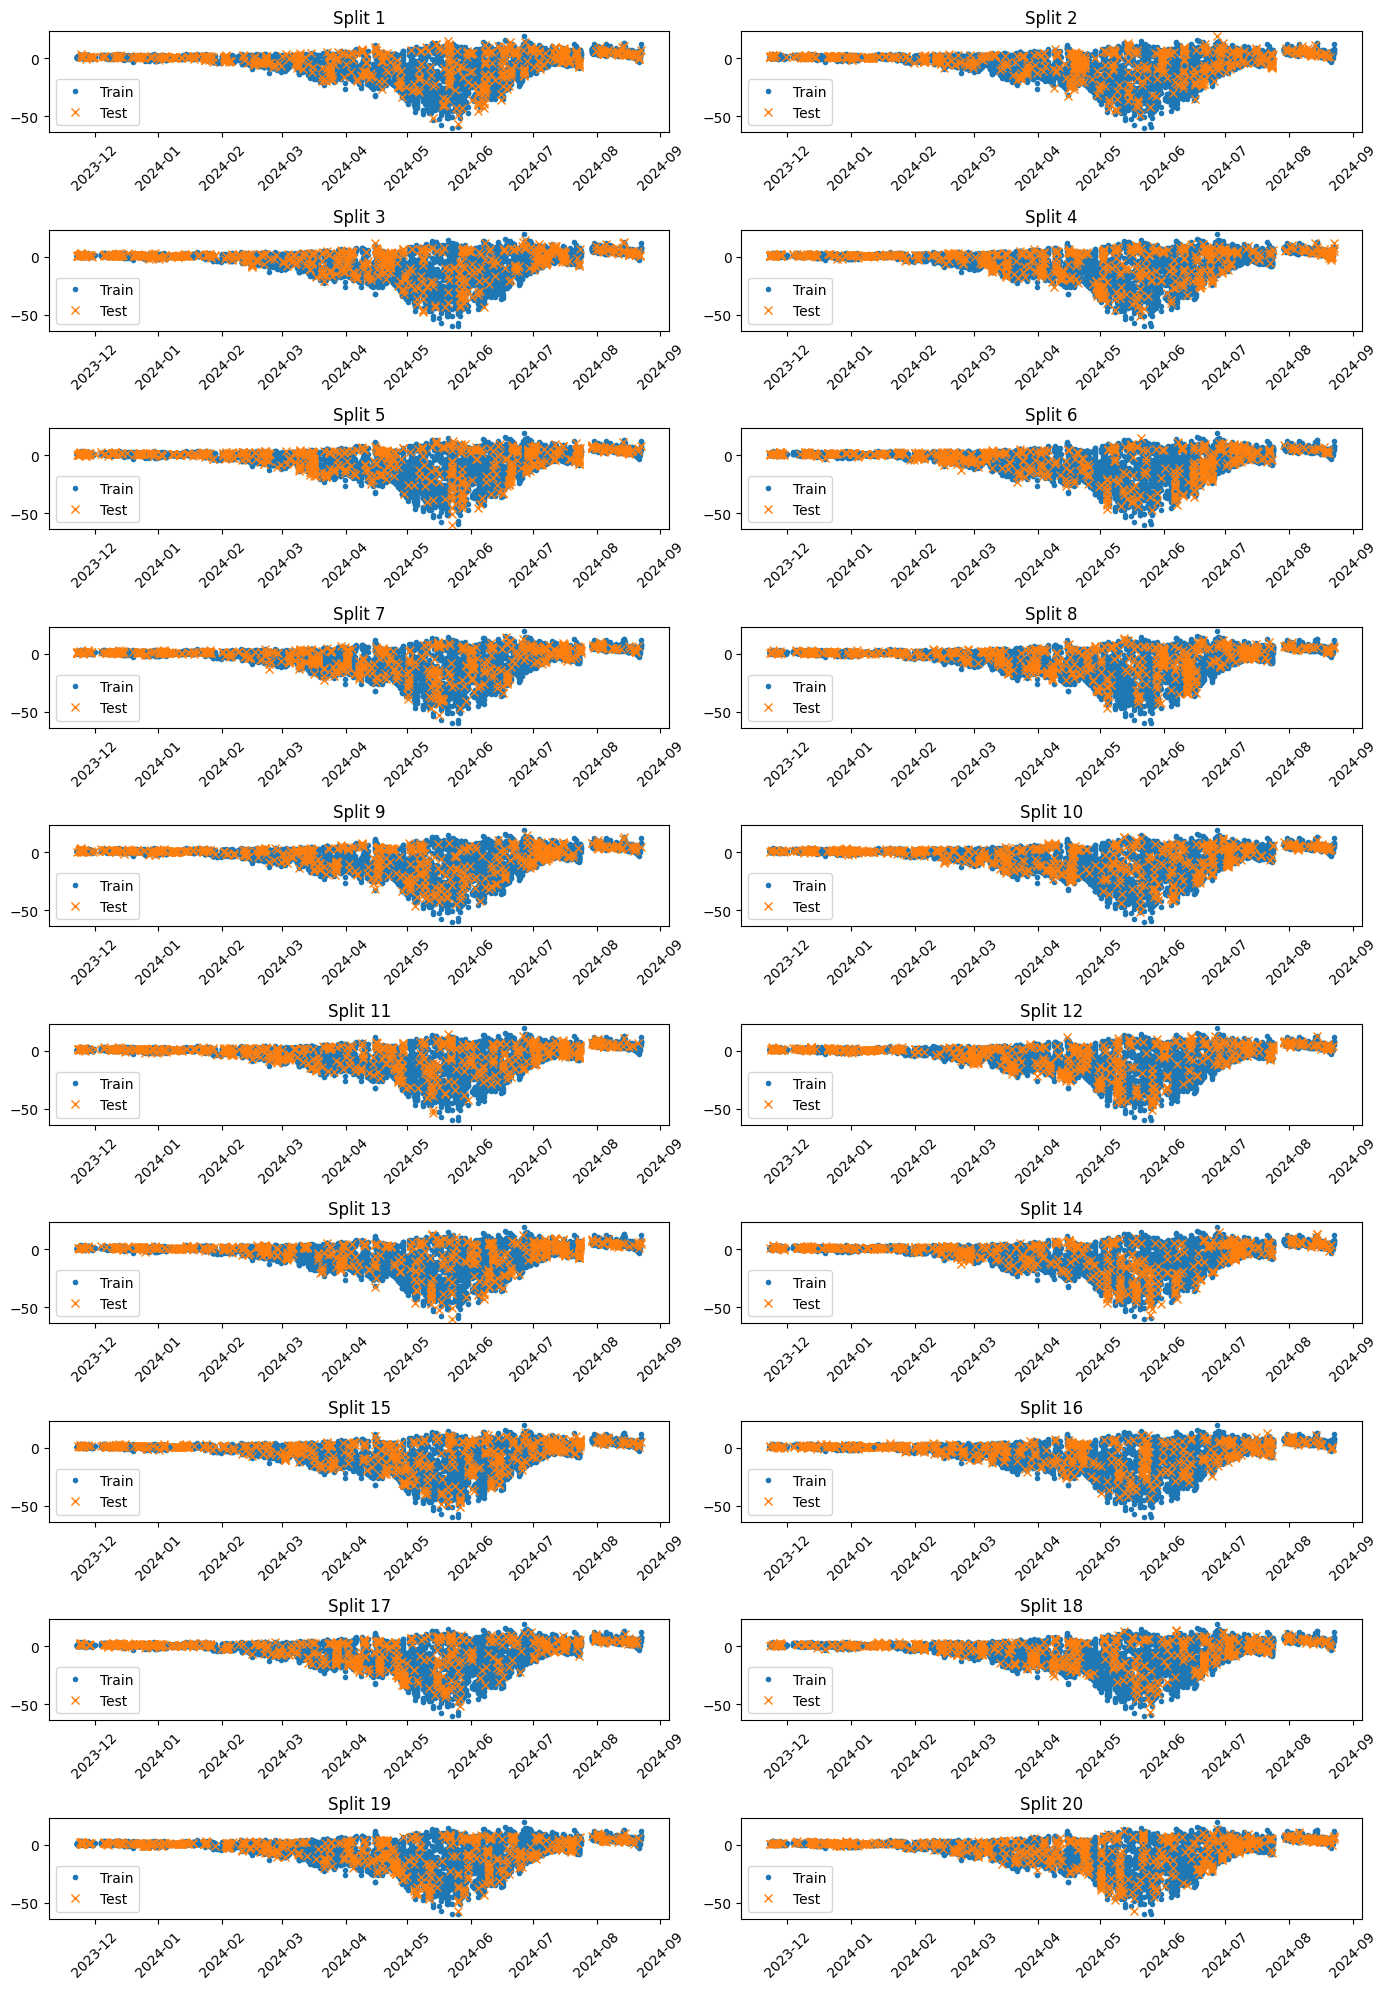

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_16_QCF0
  RMSE:   1.8361
  MAE:    1.1327
  R2:     0.9719
----------------------------------------
Fitting final model on full training set...


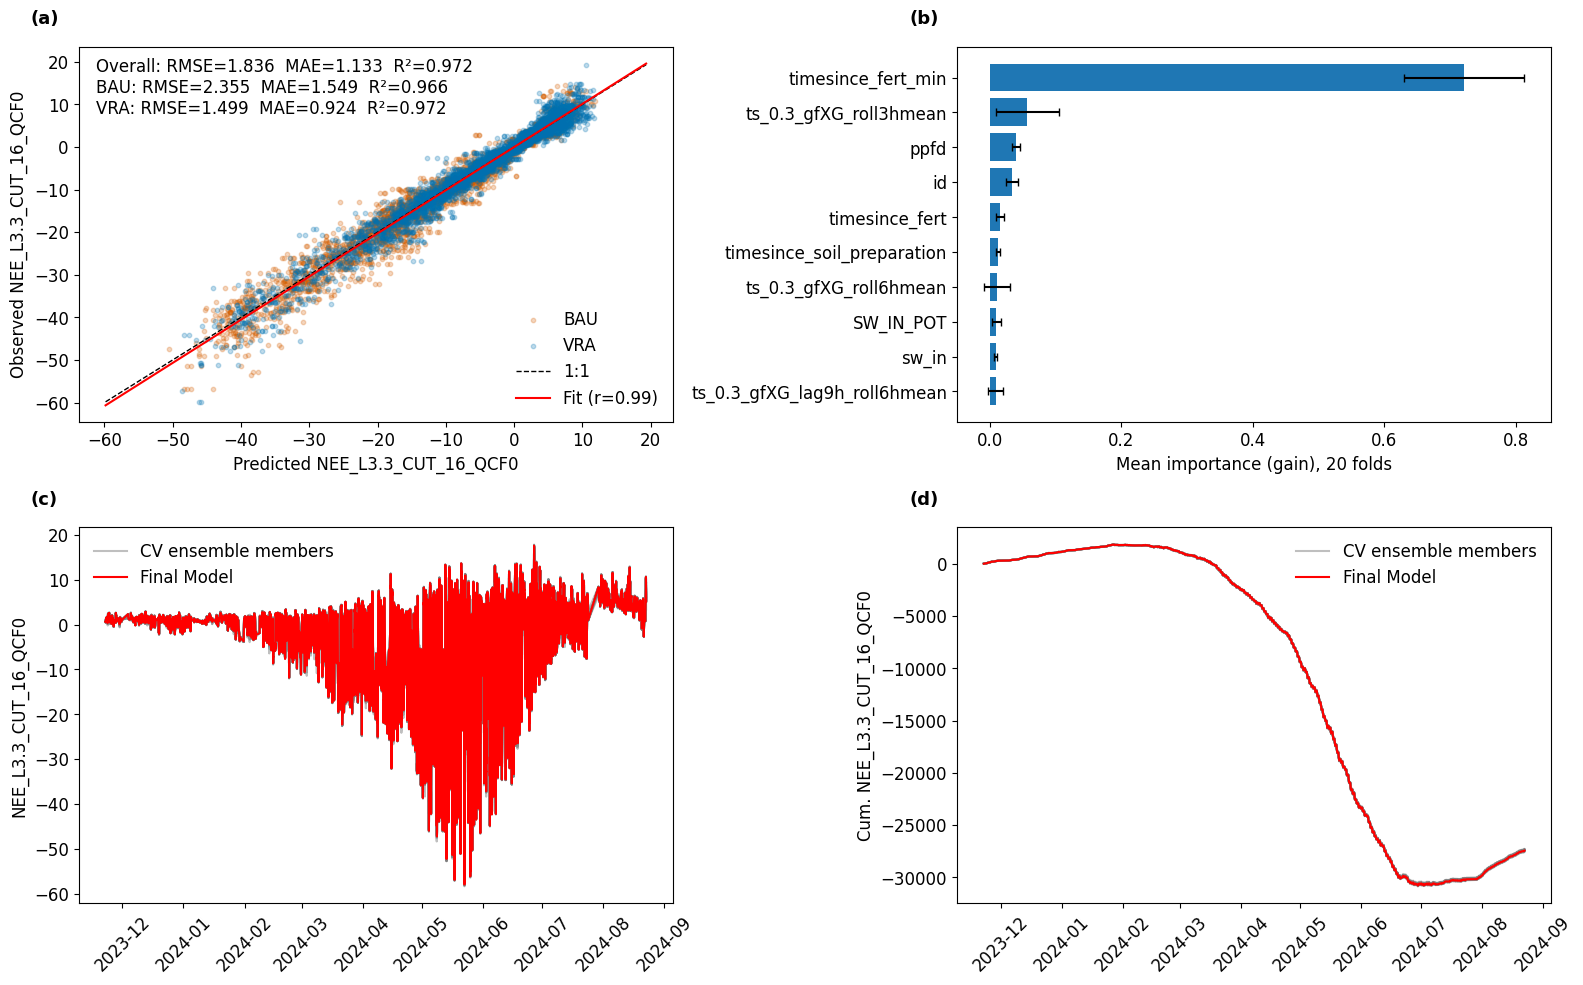

Finished training. Ensemble size (folds): 20


In [7]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

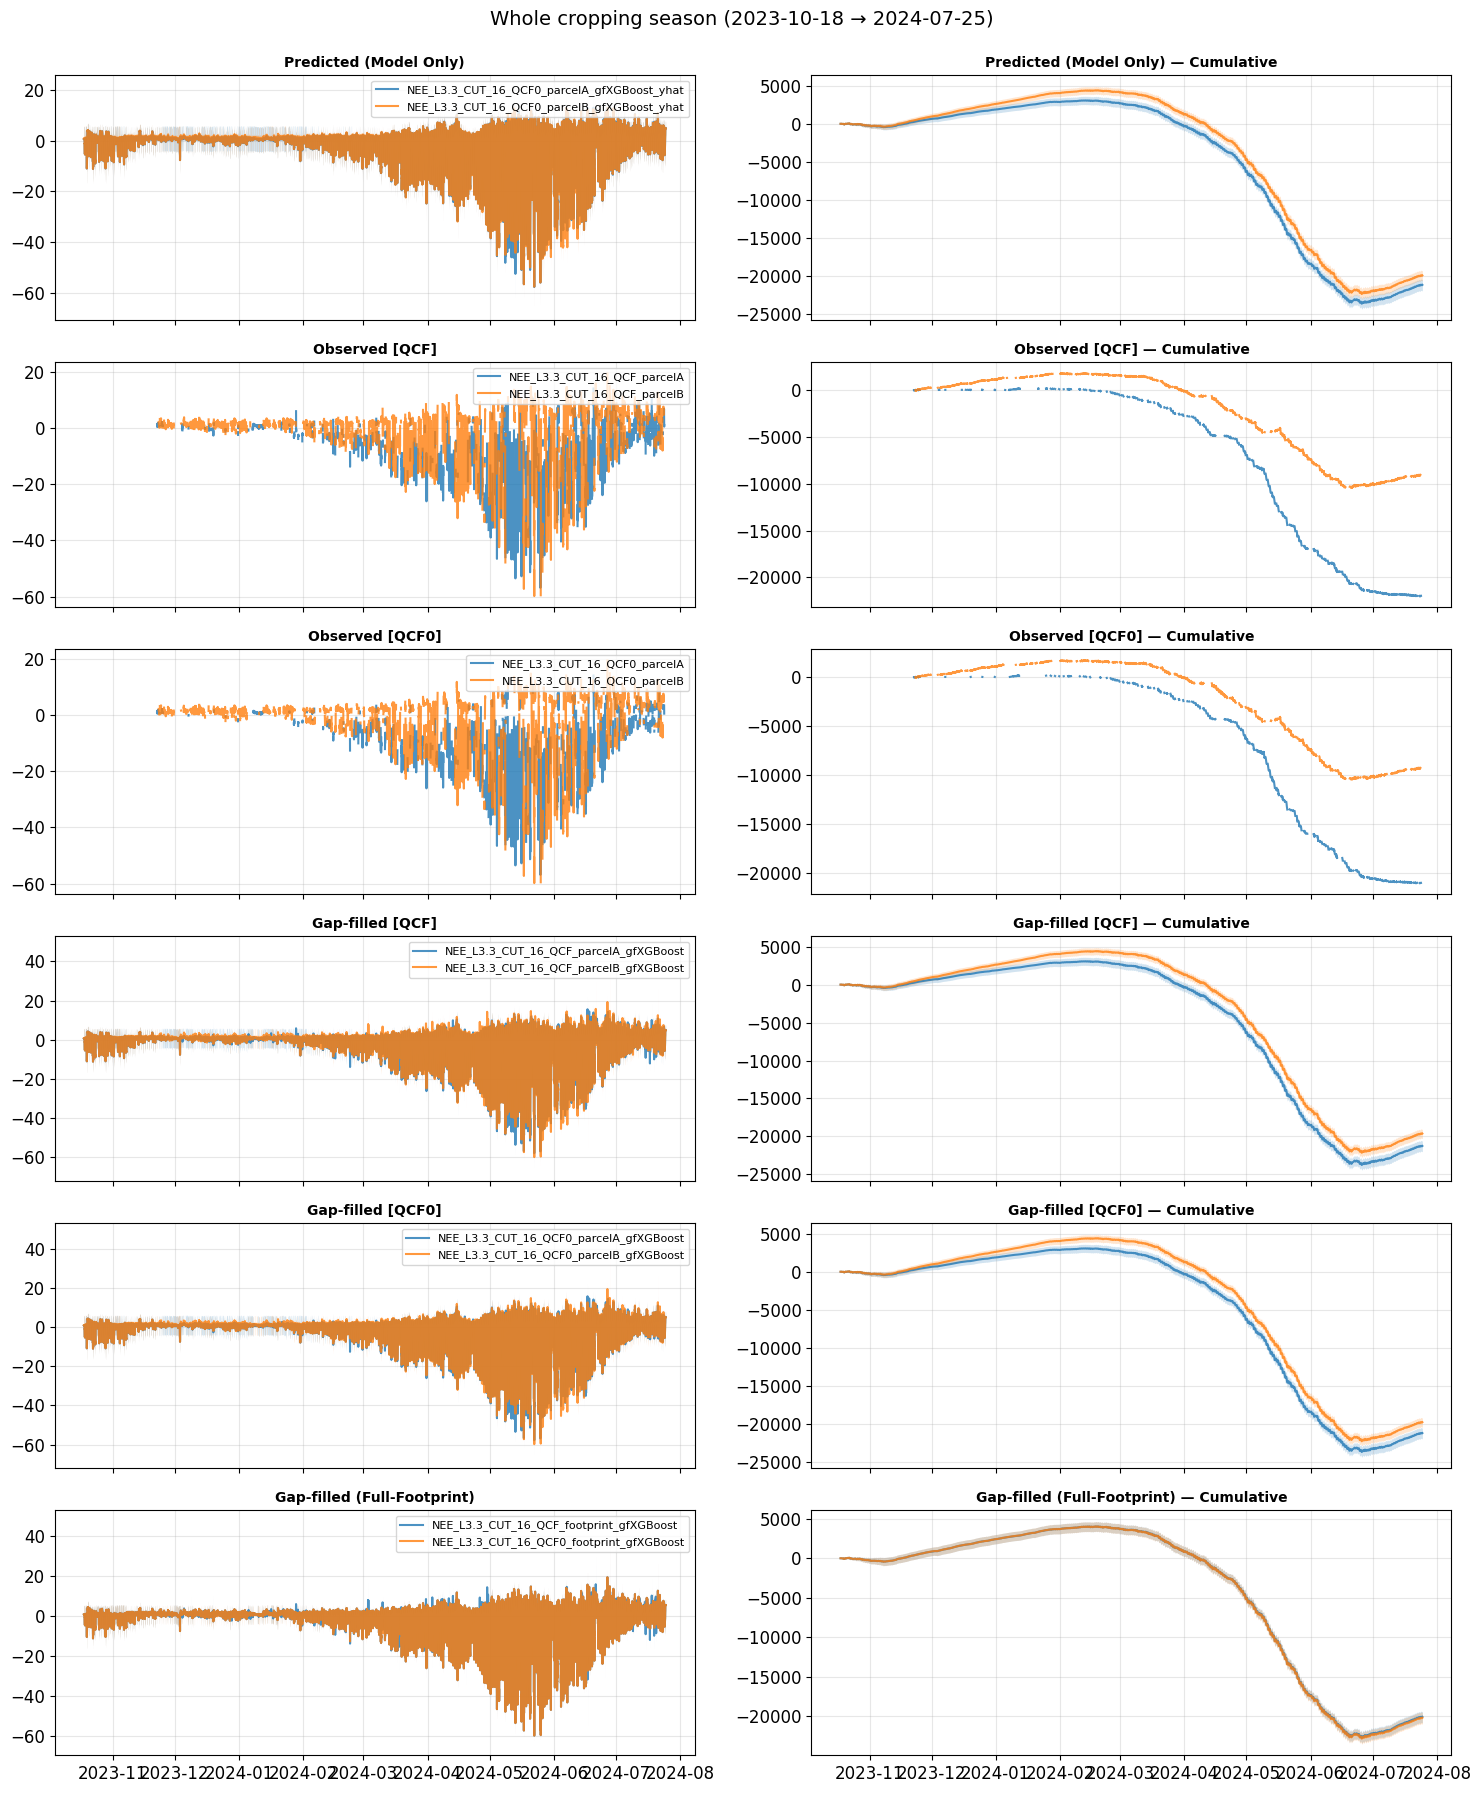

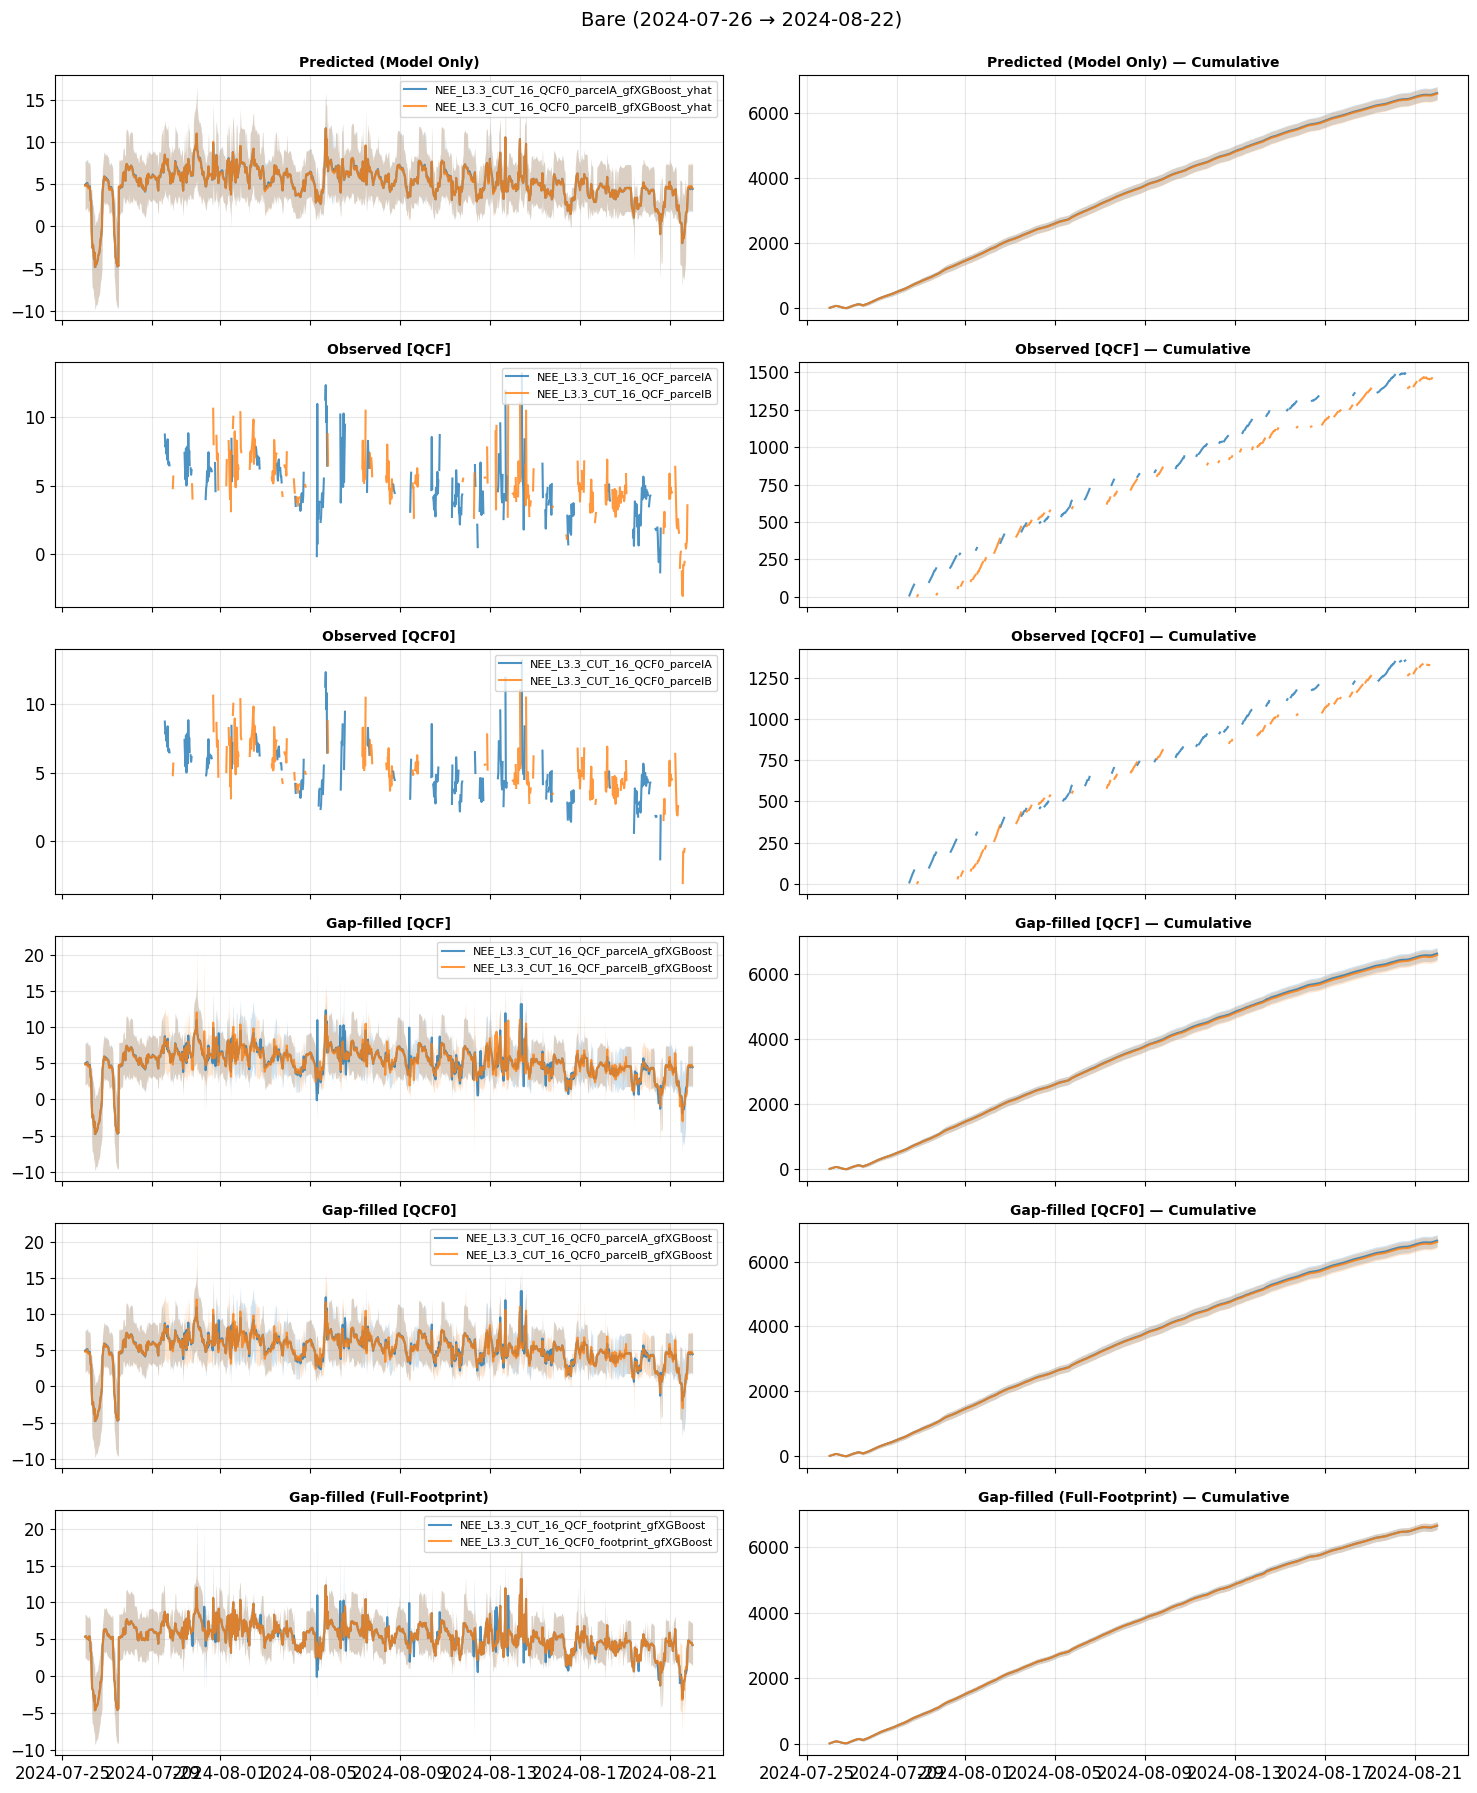

In [8]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)

views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target=TARGET,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-10-18", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT16
df_CUT16 = df_final.copy()

## CUT-50

In [9]:
USTAR_CUT = 'CUT_50'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_50_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 0.4507; raw baseline 8.8228)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 726/5715 rows never held out (12.7%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_50_QCF0
  RMSE:   1.8518
  MAE:    1.0936
  R2:     0.9713
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 0.5285; raw baseline 8.8917)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 776/6564 rows never held out (11.8%); mean times 

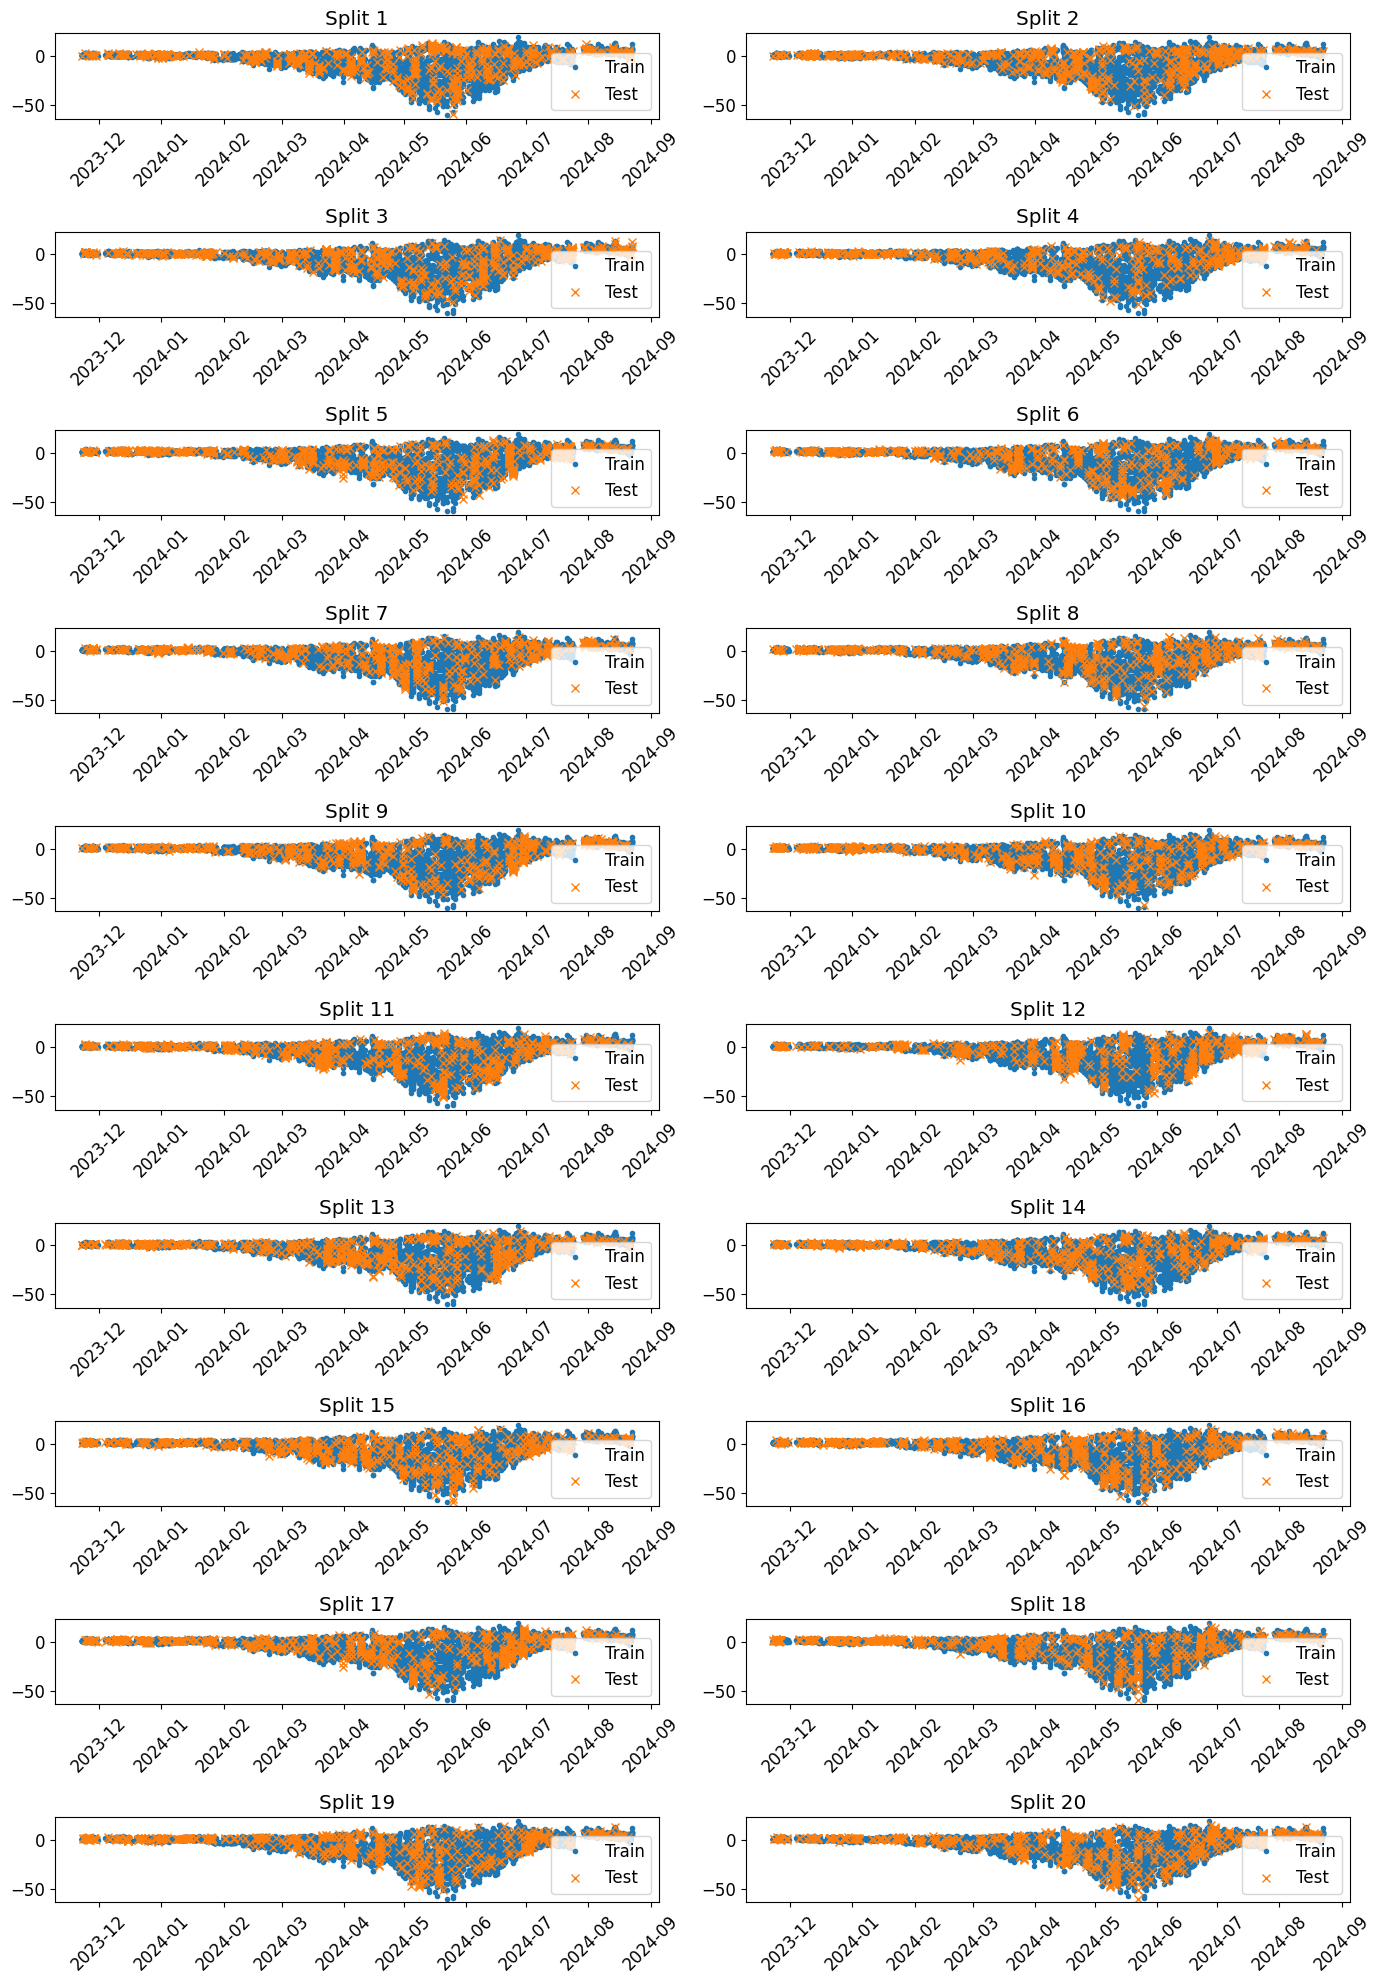

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_50_QCF0
  RMSE:   1.8843
  MAE:    1.1556
  R2:     0.9729
----------------------------------------
Fitting final model on full training set...


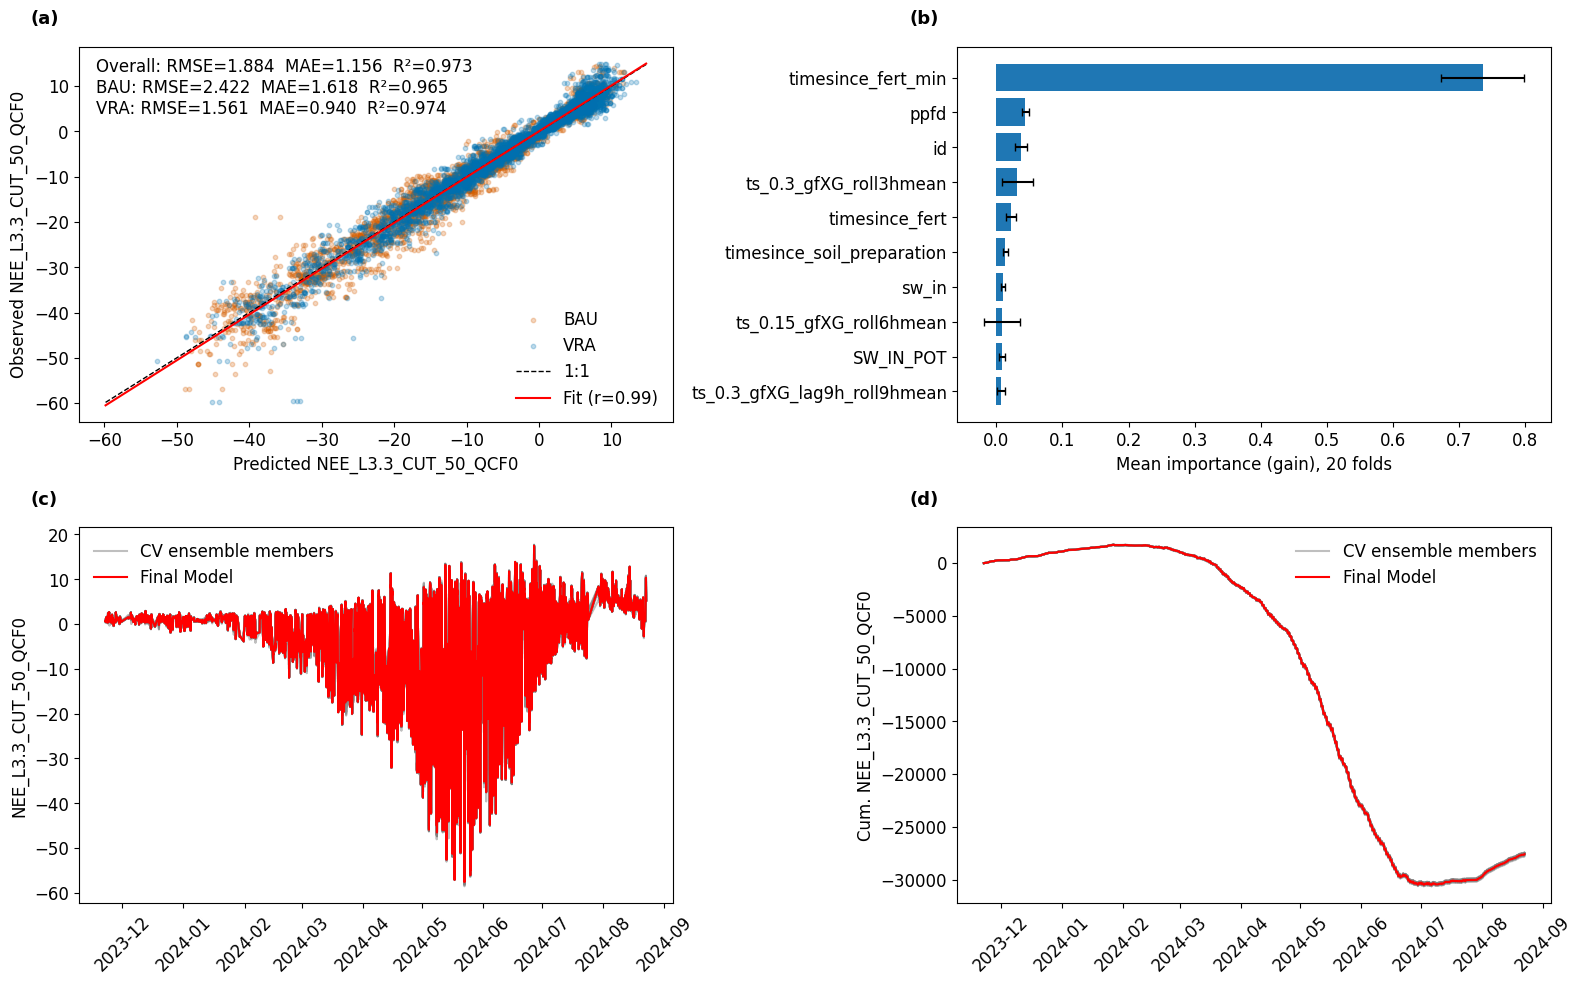

Finished training. Ensemble size (folds): 20


In [10]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

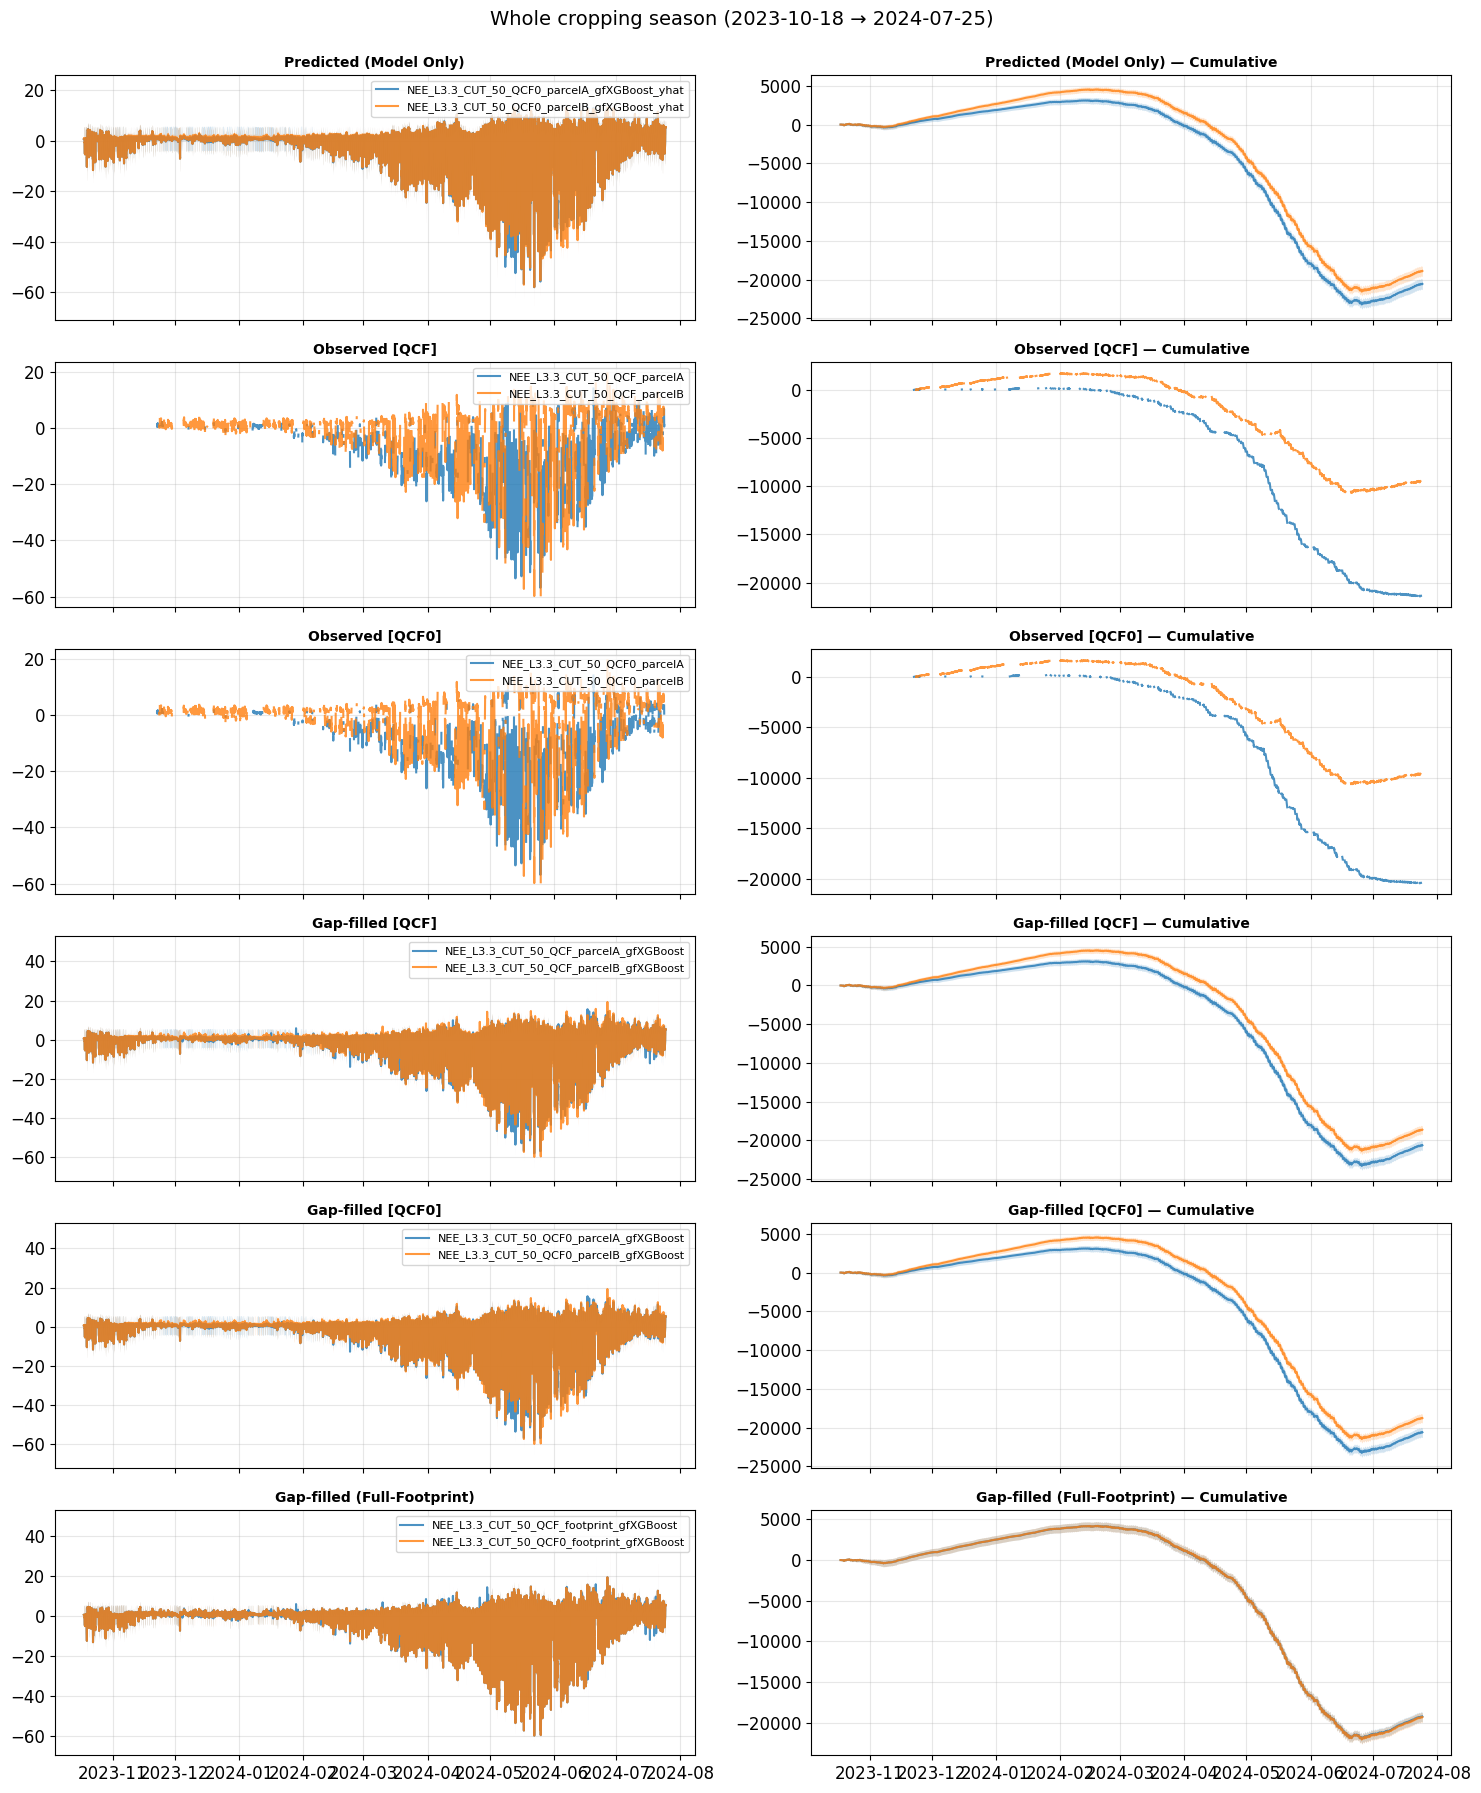

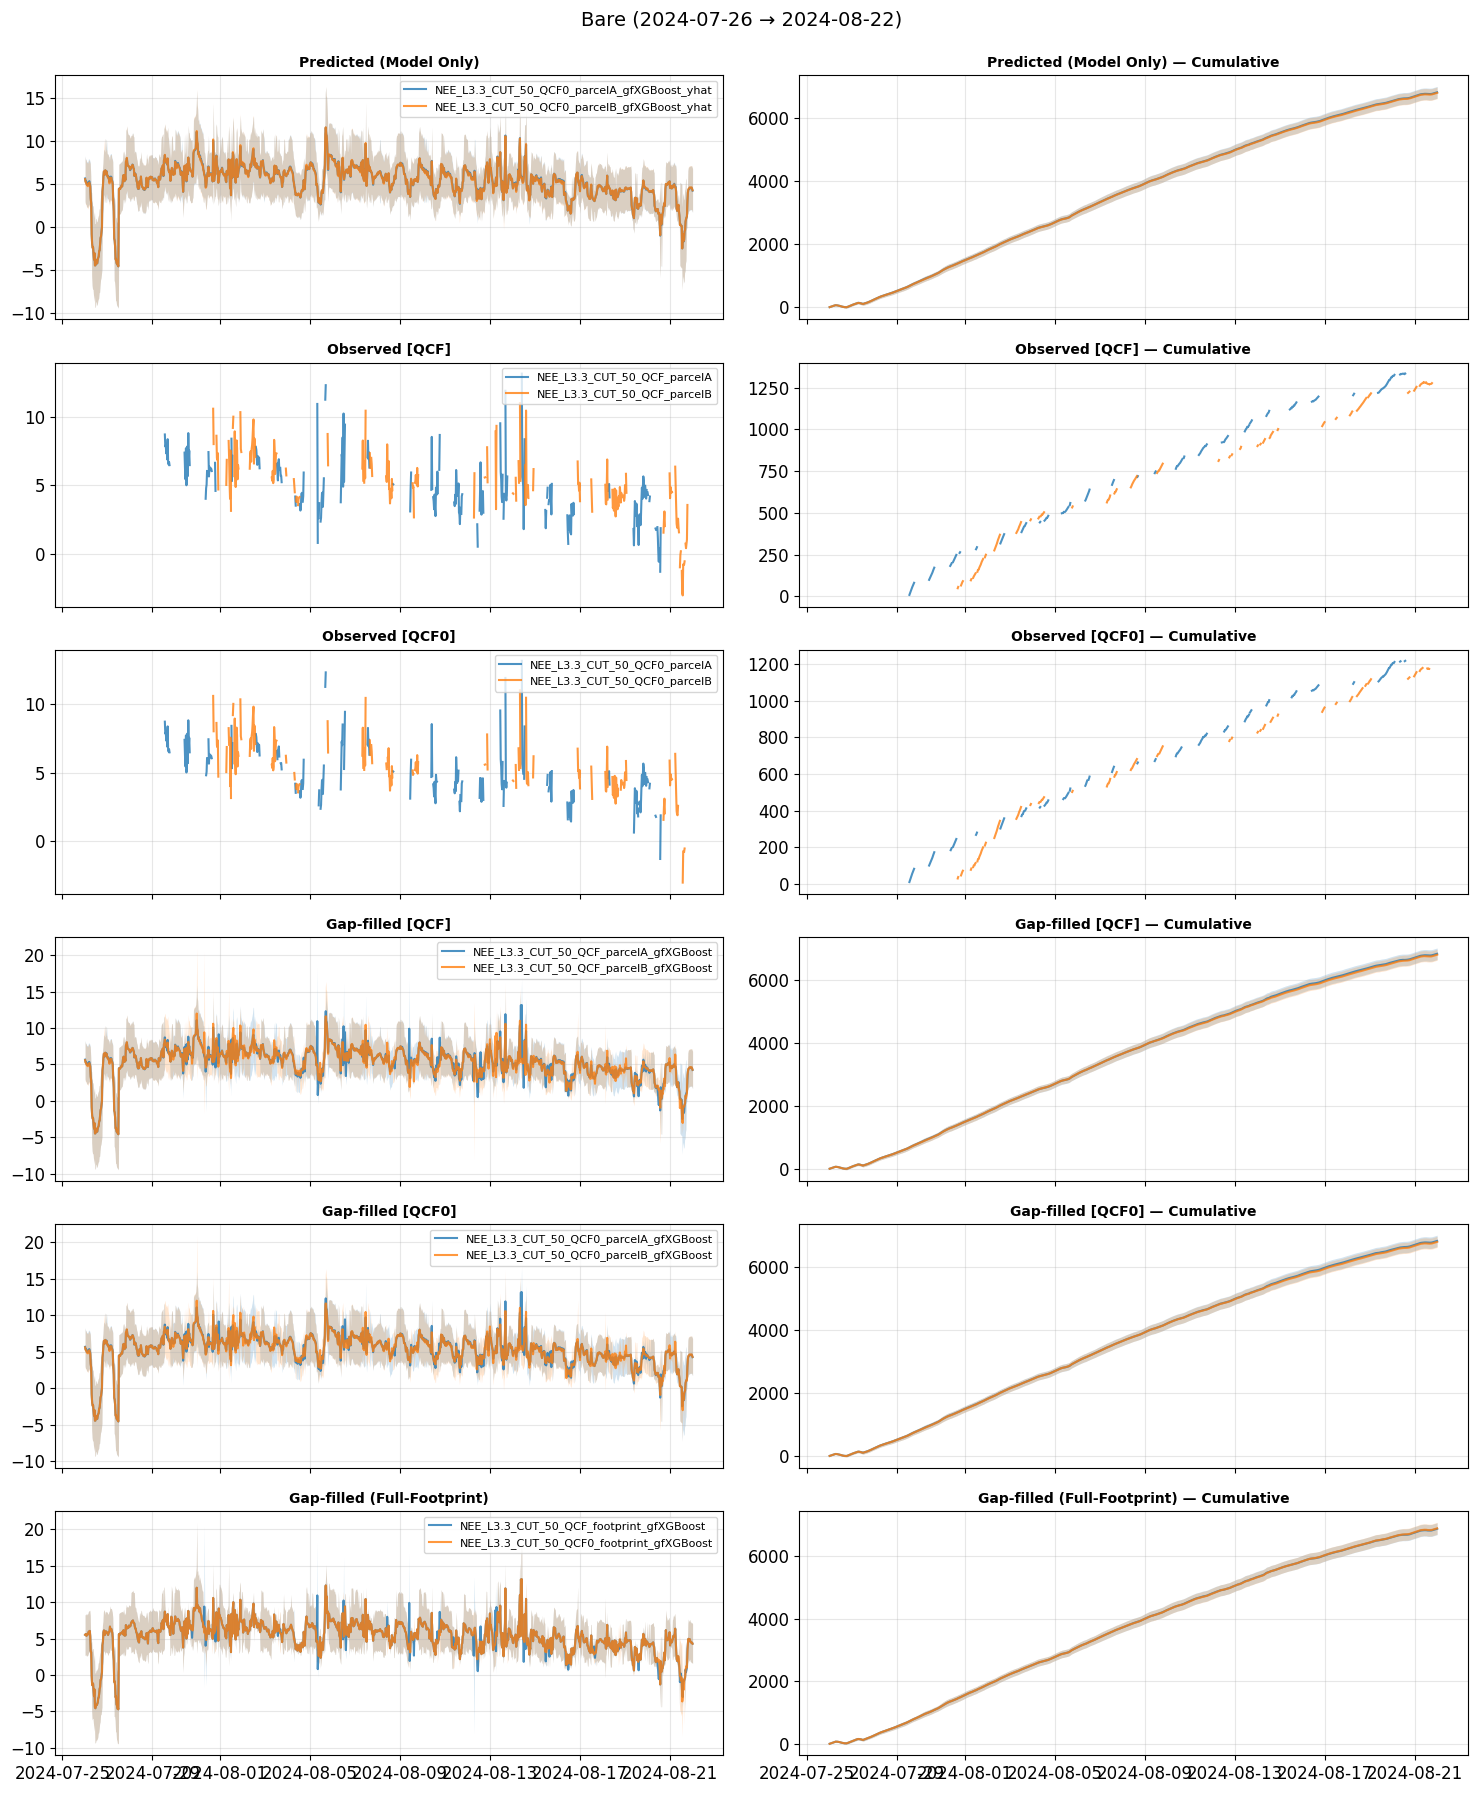

In [11]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-10-18", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT50
df_CUT50 = df_final.copy()

### SHAP CHECK

100%|===================| 11446/11448 [11:43<00:00]        

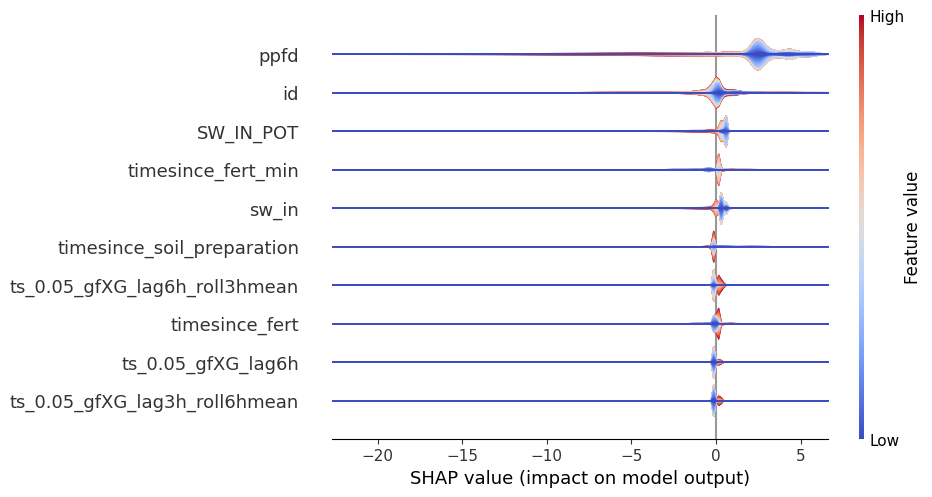

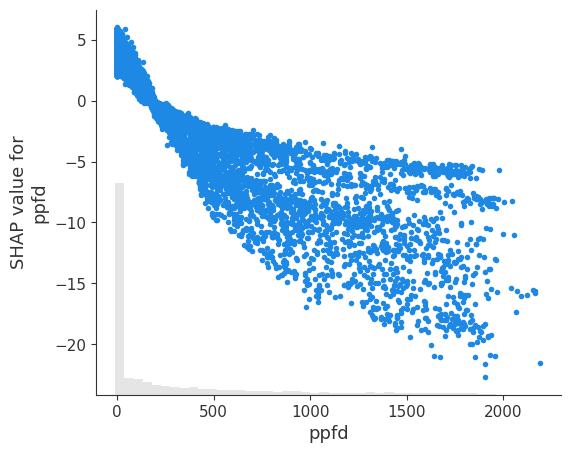

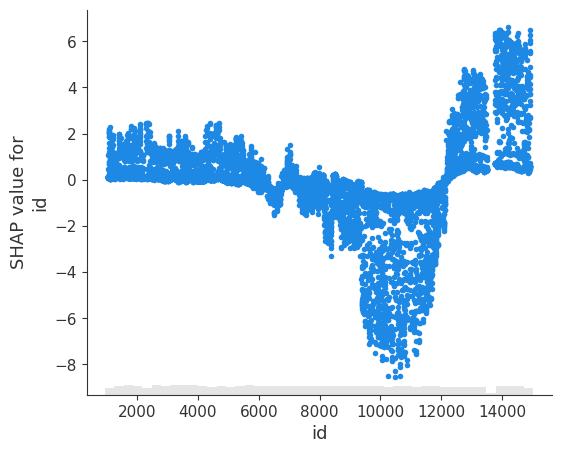

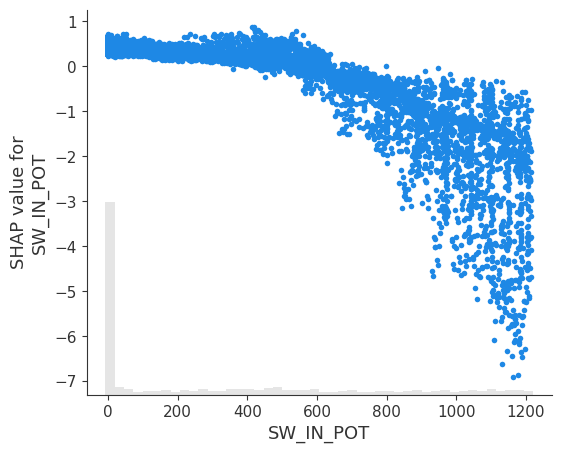

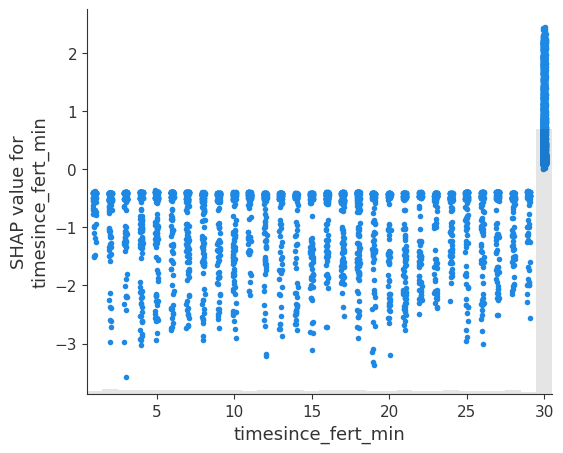

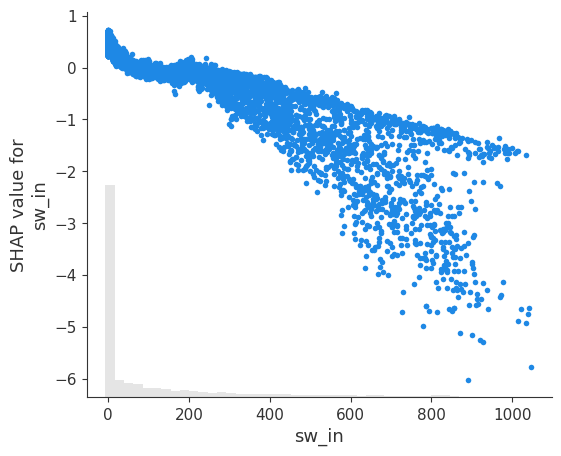

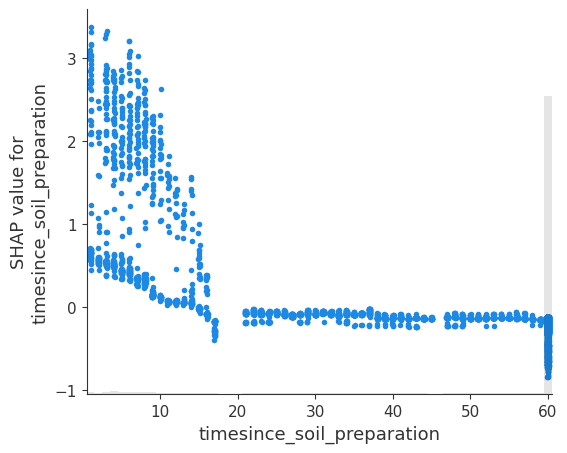

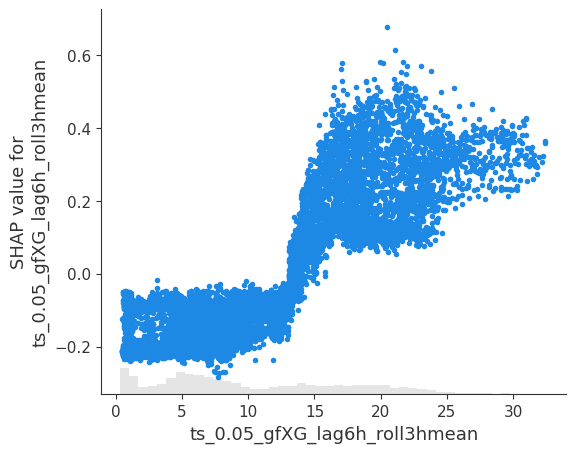

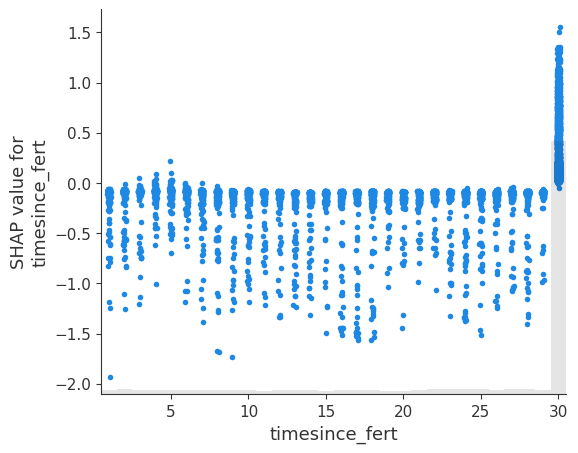

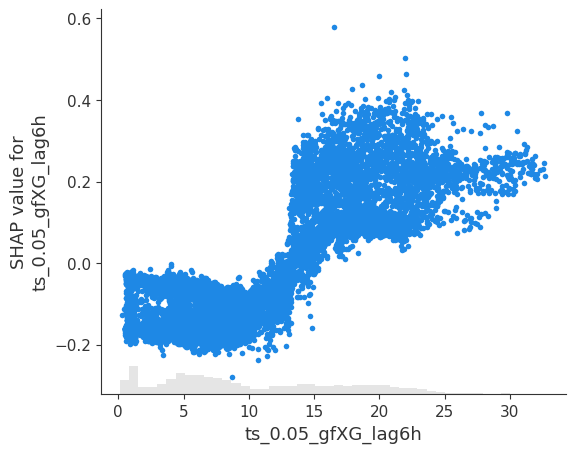

In [12]:
if SHAP_CHECK:

    # Initialize the SHAP explainer
    X = data_main[selected_features]
    explainer = shap.TreeExplainer(fit.model_final, data=X)

    # Calculate SHAP values
    shap_values = explainer(X, check_additivity=True)

    # Violin summary plot for top 10 features
    shap.plots.violin(shap_values, features=X, plot_type="layered_violin", max_display=10)
    plt.show()

    # Scatter plots of top 10 most important features
    for i in range(-1, -10, -1):
        shap.plots.scatter(shap_values[:, shap_values.abs.mean(0).argsort[i]])
        plt.show()

## CUT-84

In [13]:
USTAR_CUT = 'CUT_84'
TARGET = f'{TARGET_FLUX}_L3.3_{USTAR_CUT}_QCF0'
print(f'The target variable is {TARGET}')

The target variable is NEE_L3.3_CUT_84_QCF0


### MODEL TRAINING

Started training of the gapfilling model and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 0.5085; raw baseline 6.7425)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.103
  Coverage: 630/5260 rows never held out (12.0%); mean times held out 2.01
Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_84_QCF0
  RMSE:   1.9499
  MAE:    1.1393
  R2:     0.9705
----------------------------------------
Fitting final model on full training set...
Finished training. Ensemble size (folds): 20

Started training of the gapfilling model for the full footprint and compute gapfilling uncertainty...
  Gap distribution: fitted mixture (cvm distance 0.2286; raw baseline 7.2293)
CV Strategy: artificial gaps in real time; 20 splits; test fractions 0.100-0.106
  Coverage: 806/6010 rows never held out (13.4%); mean times 

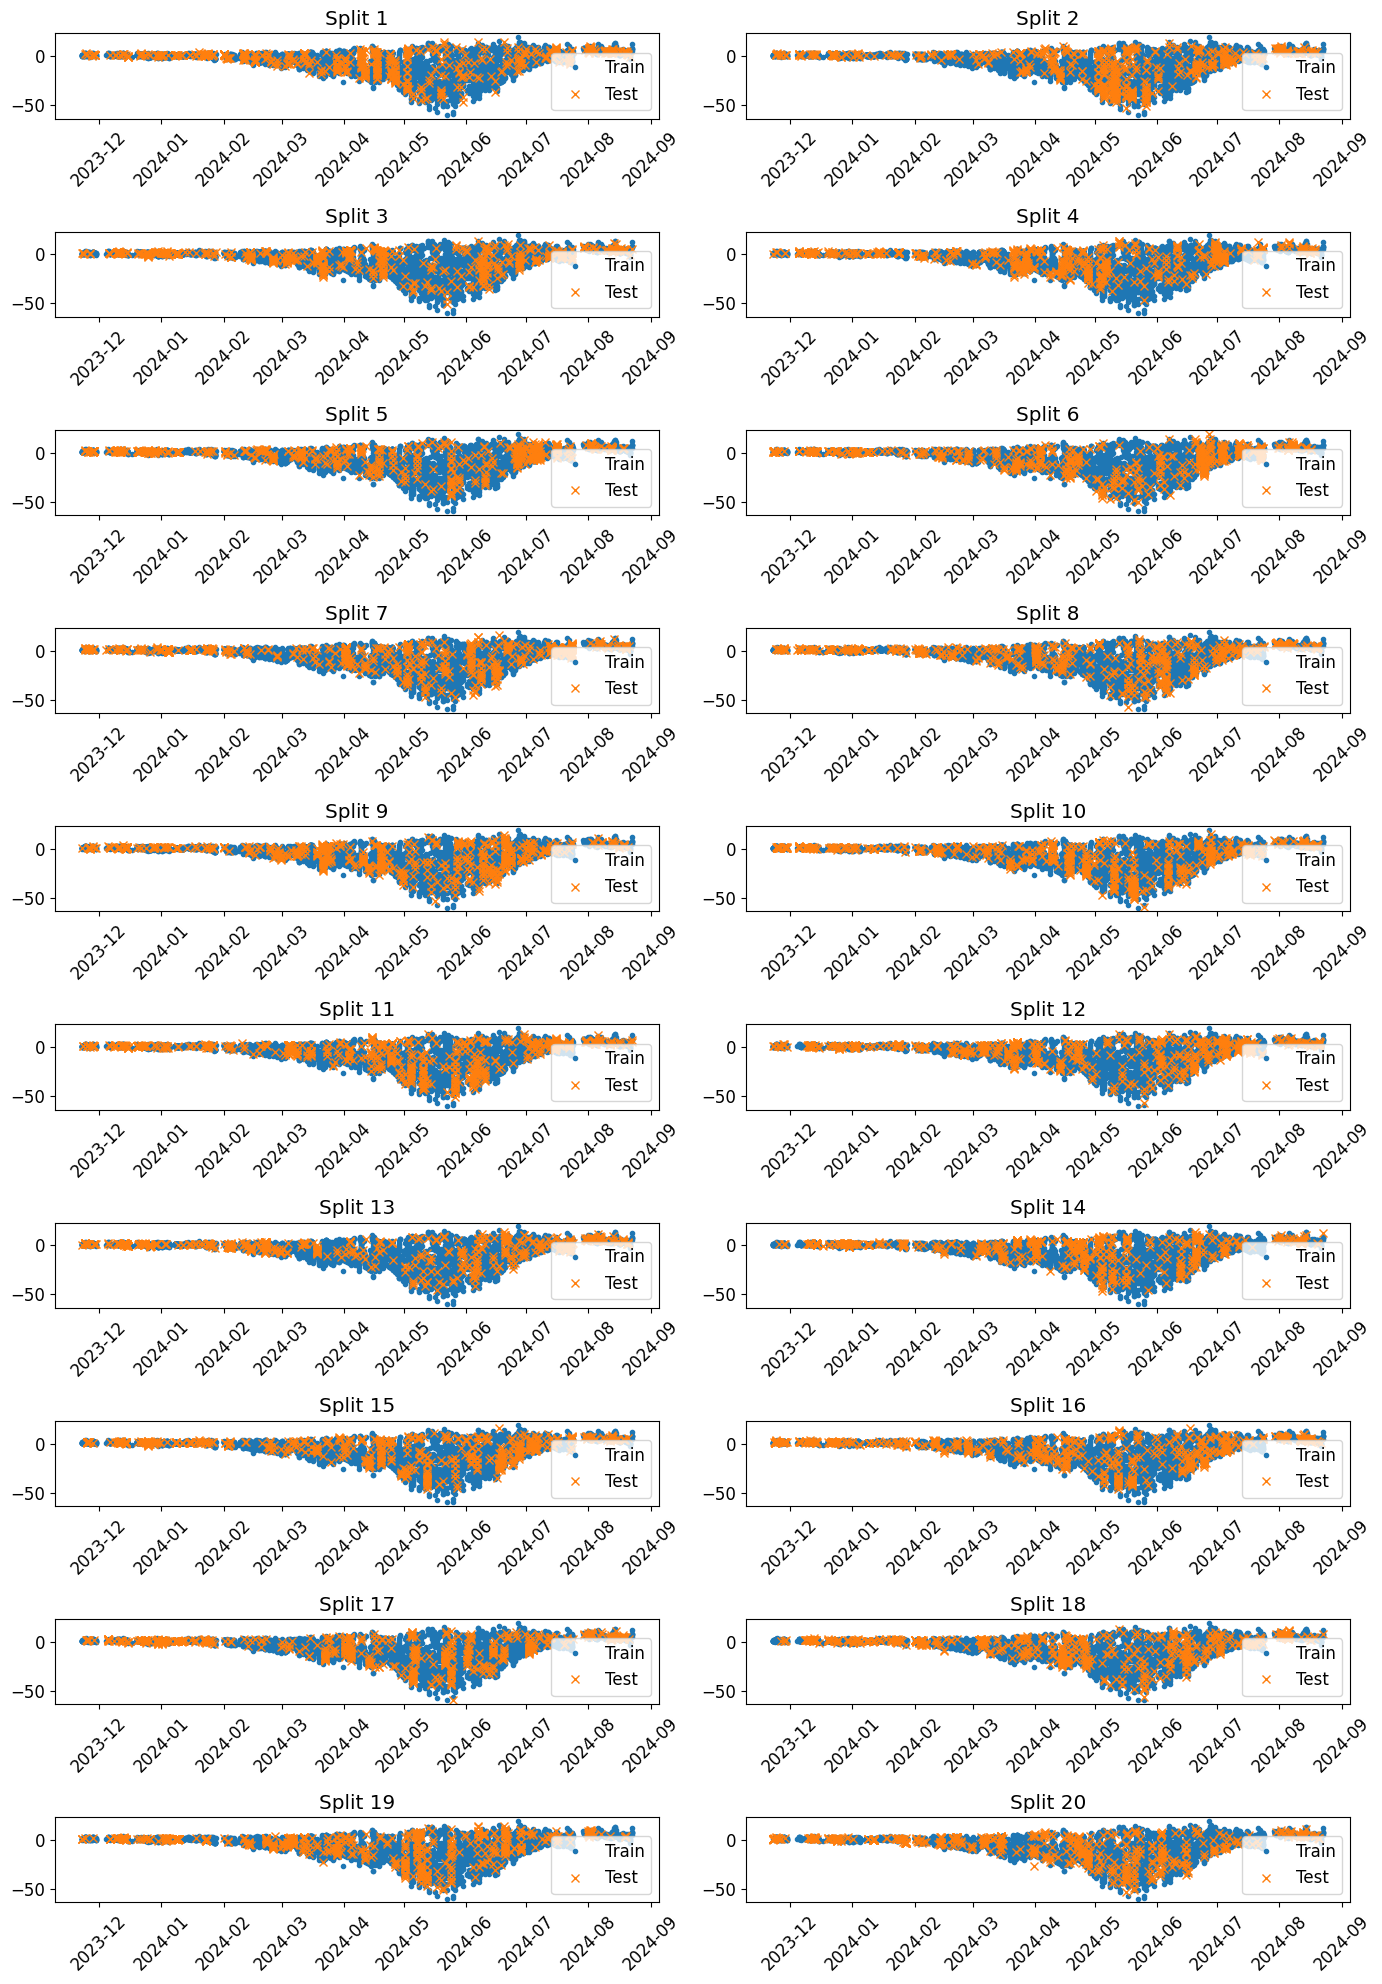

Training CV Ensemble (20 folds) & generating OOF predictions...
----------------------------------------
Gapfilling performance (mean across CV folds):
  Target: NEE_L3.3_CUT_84_QCF0
  RMSE:   1.9437
  MAE:    1.2042
  R2:     0.9722
----------------------------------------
Fitting final model on full training set...


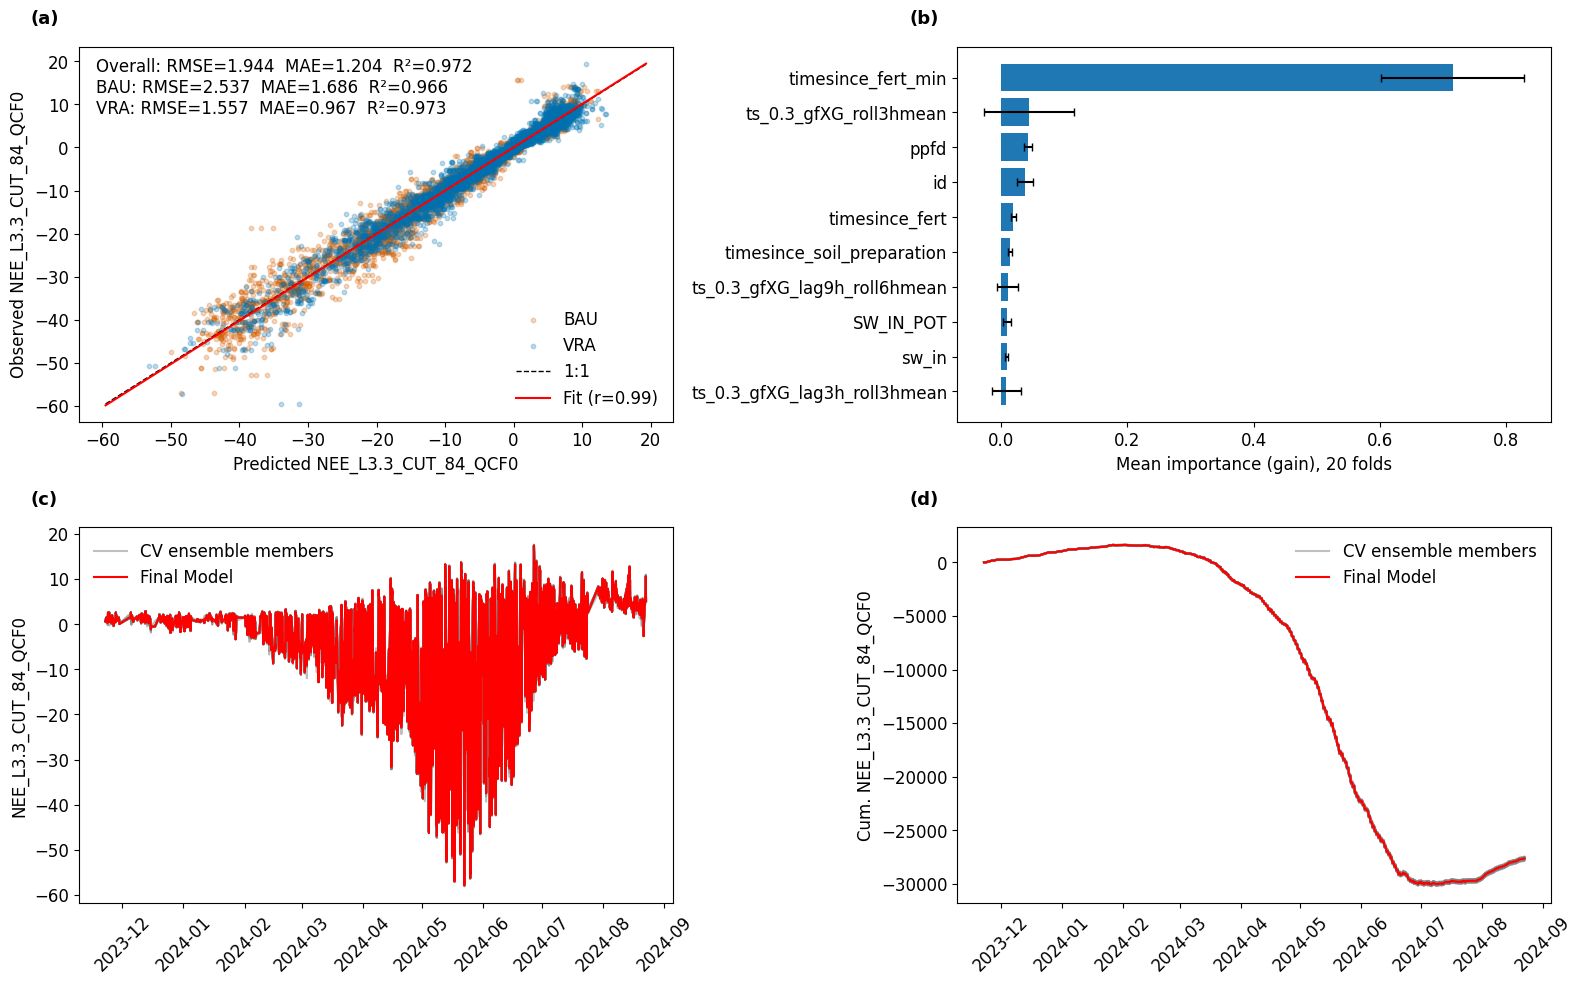

Finished training. Ensemble size (folds): 20


In [14]:
# Train ONE model to gapfill --> we train only one model for both parcels and both QCF and QCF0
print("Started training of the gapfilling model and compute gapfilling uncertainty...")
fit = fit_gapfill_ts(
    data_main,
    target_col=TARGET,
    feature_cols=selected_features,
    model_factory=model_factory,
    log_transform=LOG_TRANSFORM,      
    undersample=UNDERSAMPLE,    
    plot=False
)
print(f"Finished training. Ensemble size (folds): {len(fit.ensemble_models)}")

# Train ONE model to gapfill the footprint if only confident assignments were used before
if PARCEL_CERTAIN:
    # we train only one model for both parcels and both QCF and QCF0
    print("\nStarted training of the gapfilling model for the full footprint and compute gapfilling uncertainty...")
    fit_footprint = fit_gapfill_ts(
        maindf,
        target_col=TARGET,
        feature_cols=selected_features,
        model_factory=model_factory,
        log_transform=LOG_TRANSFORM,      
        undersample=UNDERSAMPLE,    
        plot=True
    )
    print(f"Finished training. Ensemble size (folds): {len(fit_footprint.ensemble_models)}")

### GAPFILLING

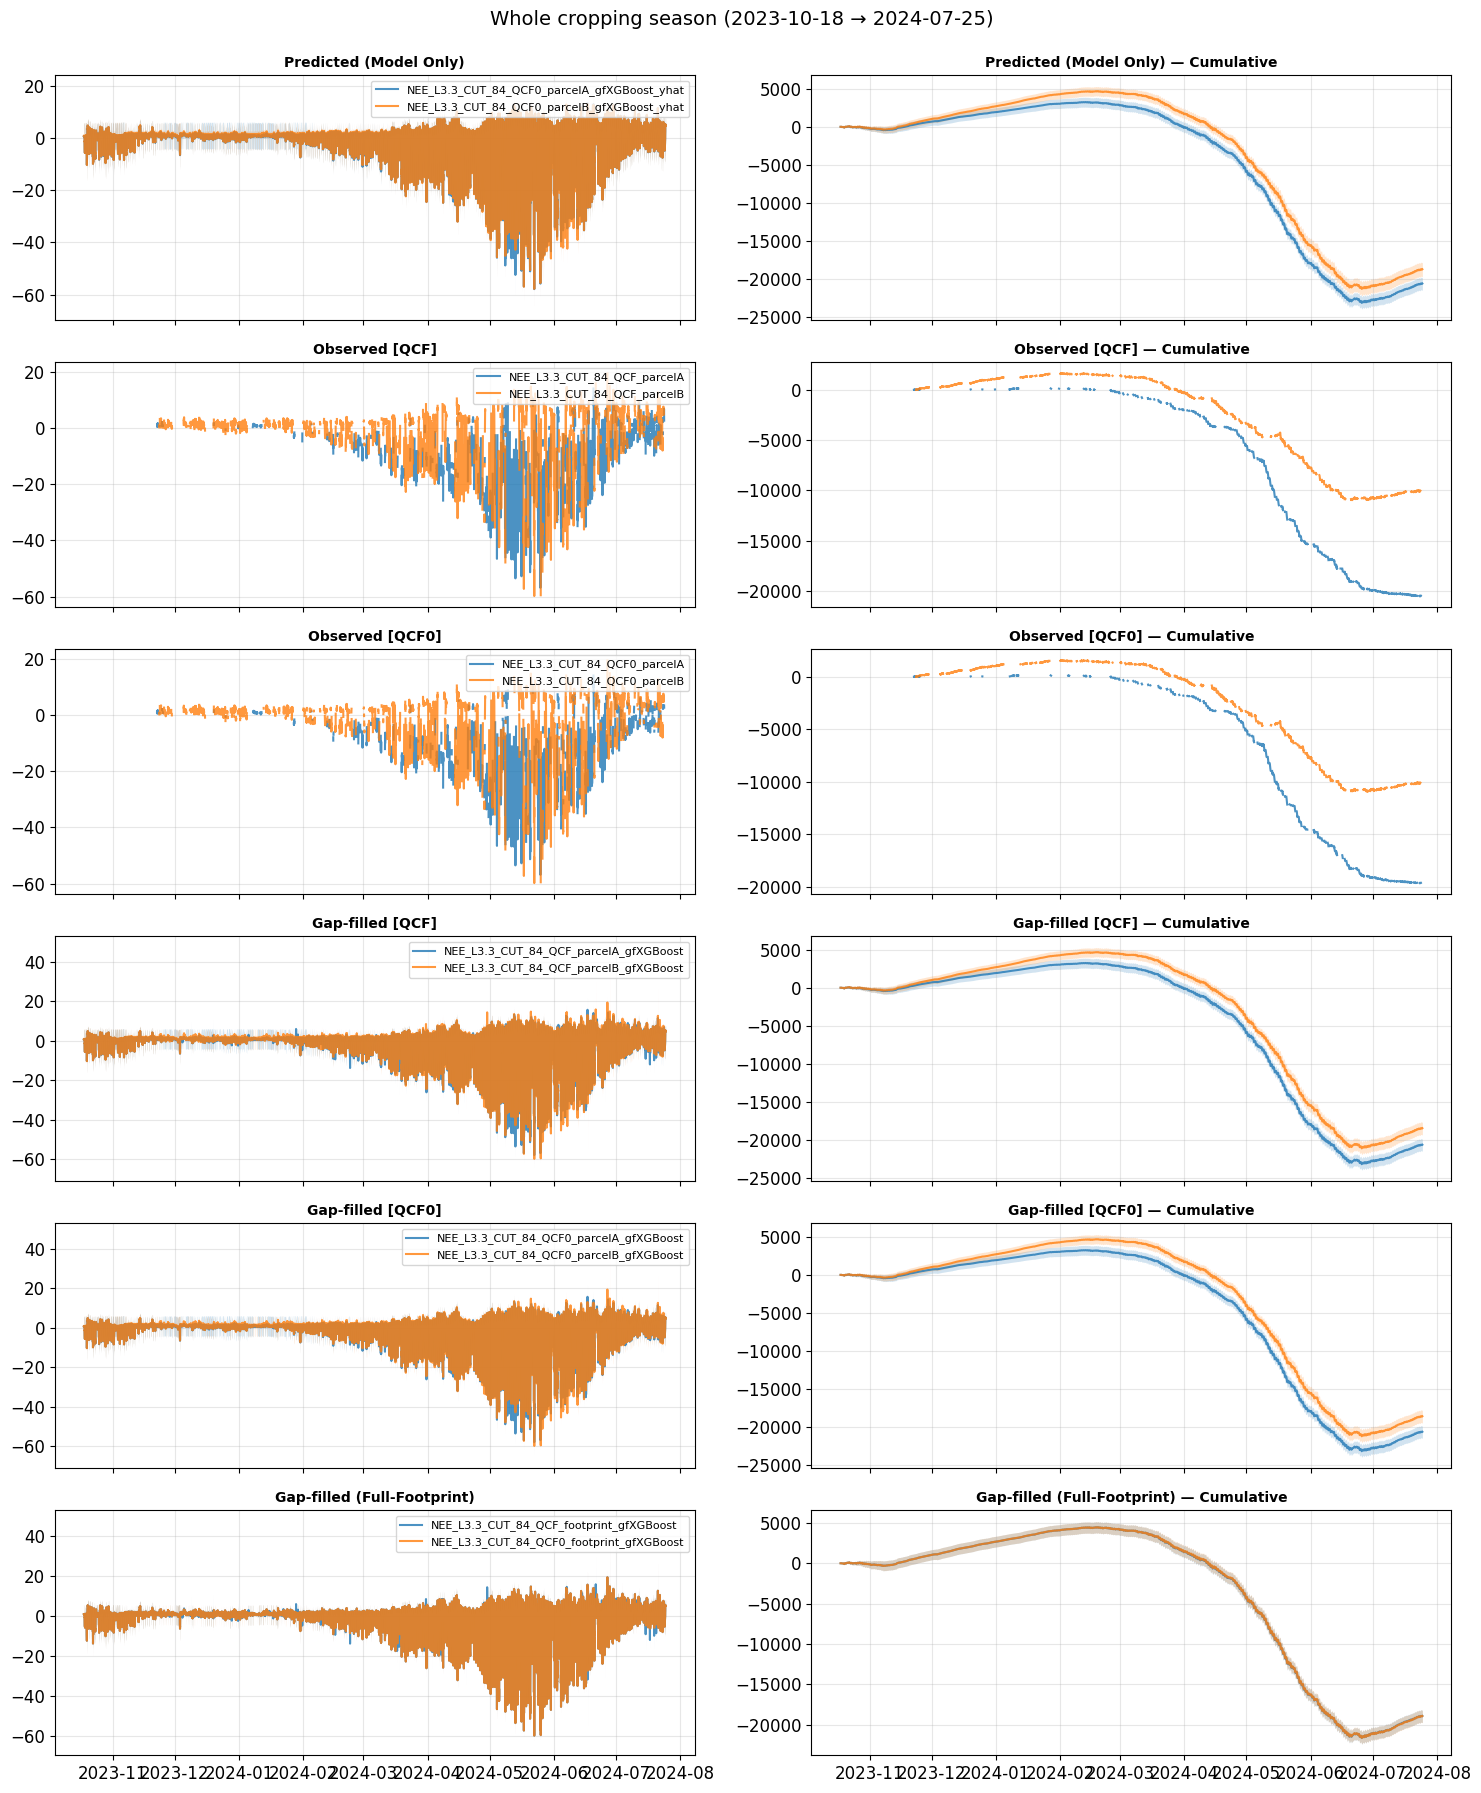

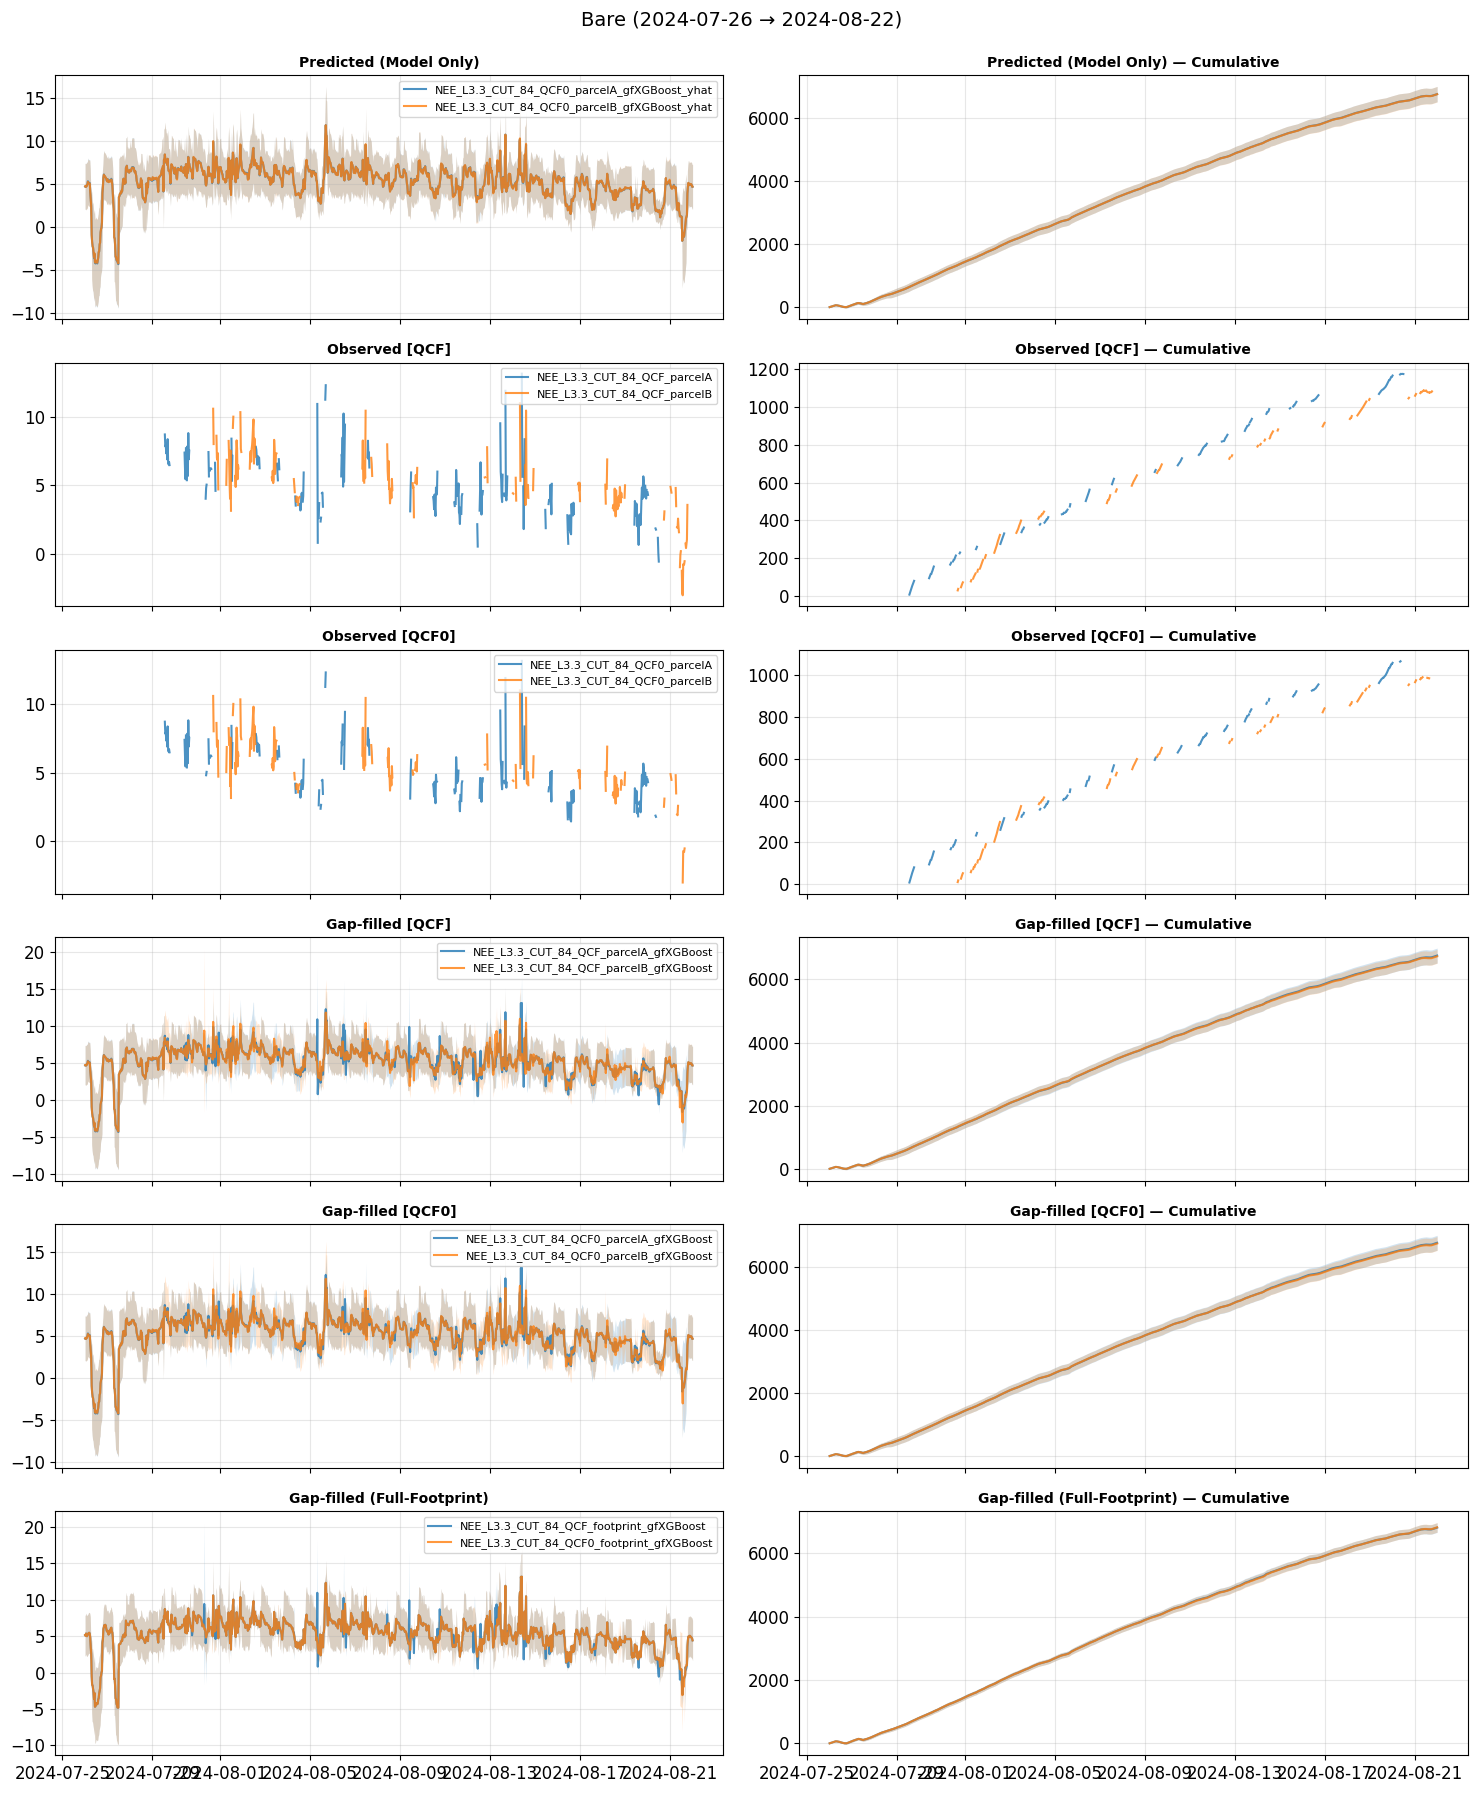

In [15]:
# Setup Views
df_fp = maindf.copy()
df_A  = build_df_for_parcel(maindf, TARGET_FLUX, "A", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_A = df_A.copy()
df_A['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_A.index)
df_B  = build_df_for_parcel(maindf, TARGET_FLUX, "B", selected_features, add_trt=ADD_TRT)
# add FC_RANDUNC_HF because it was not included as the function includes only features starting with 'NEE' or selected features
df_B = df_B.copy()
df_B['FC_RANDUNC_HF'] = maindf['FC_RANDUNC_HF'].reindex(df_B.index)
views = [
    ("parcelA", df_A, apply_gapfill_ts(df_A, fit), fit),
    ("parcelB", df_B, apply_gapfill_ts(df_B, fit), fit),
]
# Add the Footprint view
if PARCEL_CERTAIN:
    # If we trained a specific model for the footprint, use it
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit_footprint), fit_footprint))
else:
    # Otherwise, apply the only model we have
    views.append(("footprint", df_fp, apply_gapfill_ts(df_fp, fit), fit))

# Merge Results
df_final, contexts = merge_gapfill_results(
    main_df=maindf,
    views=views,
    target_flux=TARGET_FLUX,      # e.g. "FN2O"
    target=TARGET,
    model_type=MODEL_TYPE,        # e.g. "XGBoost"
    ustar_cut=USTAR_CUT,           # e.g. "CUT_50"
    random_err_col=RAND_ERR_COL
)

# Plot Results
periods = [
    ("2023-10-18", "2024-07-25", "Whole cropping season"),
    ("2024-07-26", "2024-08-22", "Bare")
]
plot_gapfill_dashboard(
    df=df_final,
    periods=periods,
    target_flux=TARGET_FLUX,
    target=TARGET,
    model_type=MODEL_TYPE,
    ustar_cut=USTAR_CUT,
    contexts=contexts
)

# Create a copy of the final dataframe for CUT84
df_CUT84 = df_final.copy()

# MERGE RESULTS

In [16]:
newcols_CUT16 = [c for c in df_CUT16.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")
display(newcols_CUT16)

newcols_CUT50 = [c for c in df_CUT50.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")  
display(newcols_CUT50)

newcols_CUT84 = [c for c in df_CUT84.columns if c not in maindf]
print(f"NEW VARIABLES FROM GAP-FILLING {TARGET}:")     
display(newcols_CUT84)

# Merge the new columns into a single dataframe
gapfilled_df = pd.concat([df_CUT16[newcols_CUT16], df_CUT50[newcols_CUT50], df_CUT84[newcols_CUT84]], axis=1)

gapfilled_df

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_16_QCF_parcelA',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoos

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_50_QCF_parcelA',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoos

NEW VARIABLES FROM GAP-FILLING NEE_L3.3_CUT_84_QCF0:


['NEE_L3.3_CUT_84_QCF_parcelA',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_yhat',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost',
 'FLAG_NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ISFILLED',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaGF',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaResid',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaEns',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_total_unc',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_sigmaObs',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens00',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens01',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens02',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens03',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens04',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens05',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens06',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens07',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens08',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens09',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoost_ens10',
 'NEE_L3.3_CUT_84_QCF_parcelA_gfXGBoos

,NEE_L3.3_CUT_16_QCF_parcelA,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_16_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens05,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens06,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens07,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens08,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens09,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens10,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_84_QCF0_footprint_gfXGBoost_ens19
TIMESTAMP_MIDDLE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-17 00:15:00,NaN,4.588344,4.588344,1,1.517483,1.404549,0.574454,1.517483,NaN,4.864410,4.133822,3.461763,3.898839,4.392054,5.065650,...,4.159542,5.479325,5.486156,5.842497,6.098002,5.997335,6.129688,6.274002,6.255286,5.207161,6.022611,5.630491,6.008531,4.158511,6.498959
2023-10-17 00:45:00,NaN,4.588344,4.588344,1,1.517978,1.404549,0.575760,1.517978,NaN,4.879979,4.137067,3.461763,3.898839,4.392054,5.065650,...,4.159542,5.479325,5.486156,5.842497,6.098002,5.997335,6.129688,6.274002,6.255286,5.207161,6.035096,5.630491,6.008531,4.158511,6.498959
2023-10-17 01:15:00,NaN,4.588344,4.588344,1,1.519817,1.404549,0.580591,1.519817,NaN,4.879979,4.137067,3.461763,3.888326,4.392054,5.127068,...,4.159542,5.479325,5.485127,5.842497,6.096806,5.997335,6.126984,6.274002,6.255286,5.207161,6.035096,5.630491,6.008531,4.158511,6.498959
2023-10-17 01:45:00,NaN,4.588344,4.588344,1,1.518928,1.404549,0.578261,1.518928,NaN,4.864410,4.137067,3.460015,3.888326,4.392054,5.127068,...,4.159542,5.479325,5.485127,5.842497,6.096806,5.997335,6.126984,6.274002,6.255286,5.207161,6.025538,5.630491,6.008531,4.158511,6.498959
2023-10-17 02:15:00,NaN,4.588344,4.588344,1,1.518481,1.404549,0.577084,1.518481,NaN,4.879979,4.137067,3.460015,3.888326,4.392054,5.111056,...,4.159542,5.451939,5.485127,5.842497,6.096806,6.004694,6.126984,6.242115,6.255286,5.207161,6.006851,5.627851,6.008531,4.137047,6.498959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 21:45:00,NaN,5.138743,5.138743,1,1.435312,1.404549,0.295574,1.435312,2.48319,5.315476,5.211159,5.539731,4.987913,4.851460,5.483131,...,5.912544,5.858134,5.469769,6.052450,5.357956,6.112972,5.646704,5.739465,5.410835,5.468698,6.196884,5.302804,5.925315,5.341684,5.892152
2024-08-22 22:15:00,NaN,5.188995,5.188995,1,1.448434,1.404549,0.353841,1.448434,1.96792,5.197551,5.501064,5.542127,4.730024,4.591958,5.402900,...,5.512691,5.682591,5.429472,5.690421,5.143887,5.473706,5.381833,5.229702,5.174486,5.104721,5.938176,4.821662,5.631627,5.233342,5.267423
2024-08-22 22:45:00,NaN,5.118667,5.118667,1,1.450231,1.404549,0.361125,1.450231,3.14515,5.107261,5.298507,5.287387,4.790768,4.617334,5.318227,...,5.412557,5.608435,5.319055,5.569763,5.072252,5.385814,5.277498,5.209002,5.122189,5.124244,5.820779,4.635873,5.484230,5.017087,5.143273


Cumulative plots to check differences between CUT16, CUT50 and CUT84

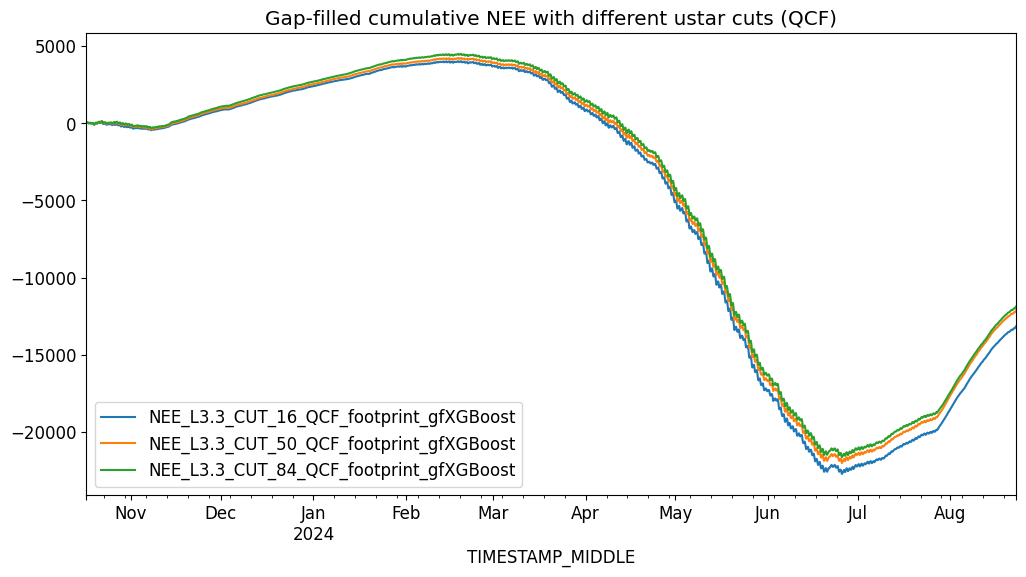

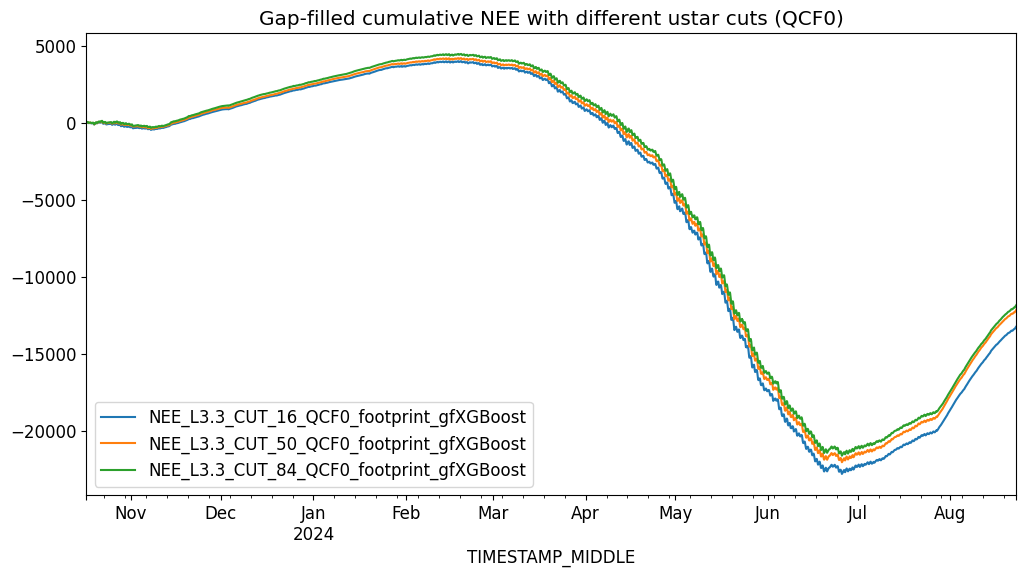

In [17]:
# Plot cumulative fluxes for different ustar cuts and QCF/QCF0
for qcf in ['QCF', 'QCF0']:
    gapfilled_df[
        [
        f'{TARGET_FLUX}_L3.3_CUT_16_{qcf}_footprint_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_50_{qcf}_footprint_gf{MODEL_TYPE}', 
        f'{TARGET_FLUX}_L3.3_CUT_84_{qcf}_footprint_gf{MODEL_TYPE}'
        ]].cumsum().plot(figsize=(12, 6), title=f'Gap-filled cumulative {TARGET_FLUX} with different ustar cuts ({qcf})')
    plt.show()

# EXPORT

In [18]:
filename = f"81.4.1_{TARGET_FLUX}_GF-{MODEL_TYPE}"
df_export = gapfilled_df.copy()
save_parquet(data=df_export, filename=filename)

Saved file 81.4.1_NEE_GF-XGBoost.parquet (1.837 seconds).


'81.4.1_NEE_GF-XGBoost.parquet'

Partitioning subset for ReddyProc

In [19]:
from diive.core.times.times import insert_timestamp
meteo = load_parquet(filepath=r"../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet")
fluxes = load_parquet(filepath=r"../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet")
ustar = fluxes['USTAR']
meteo = meteo[['ta', 'sw_in', 'vpd', 'ppfd', 'rh']]
gapfilled_nee = df_export[newcols_CUT50].copy()
export_REddyProc = pd.concat([gapfilled_nee, meteo, ustar], axis=1)
export_REddyProc = insert_timestamp(data=export_REddyProc, convention="end", set_as_index=True)
filename = "81.4.2_PartitioningSubsetForREddyProc"
export_REddyProc.to_csv(f"{filename}.csv", index=True)
print(f"Exported {filename} for partitioning of the XGBoost-gapfilled NEE")
export_REddyProc

Loaded .parquet file ../../10_METEO/13.1_CH-TAN_meteo_gapfilled.parquet (0.110 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Loaded .parquet file ../../70_SPLIT_TREATMENTS/71.1_FLUXES_L3.3_NEE_LE_H_FN2O_FCH4_REDDYPROC_PARCELS.parquet (0.397 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 
Exported 81.4.2_PartitioningSubsetForREddyProc for partitioning of the XGBoost-gapfilled NEE


,NEE_L3.3_CUT_50_QCF_parcelA,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_yhat,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost,FLAG_NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ISFILLED,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaGF,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaResid,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaEns,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_total_unc,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_sigmaObs,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens00,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens01,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens02,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens03,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens04,NEE_L3.3_CUT_50_QCF_parcelA_gfXGBoost_ens05,...,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens11,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens12,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens13,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens14,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens15,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens16,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens17,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens18,NEE_L3.3_CUT_50_QCF0_footprint_gfXGBoost_ens19,ta,sw_in,vpd,ppfd,rh,USTAR
TIMESTAMP_END,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-10-16 23:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-10-17 00:30:00,NaN,6.133102,6.133102,1.0,1.370967,1.293289,0.454920,1.370967,NaN,5.051899,5.397942,5.830239,5.927515,4.934162,5.725616,...,5.084075,5.714264,5.006567,5.585773,5.685222,6.225258,5.450644,5.658074,5.851065,1.966667,0.0,0.036616,0.0,94.800000,NaN
2023-10-17 01:00:00,NaN,6.133102,6.133102,1.0,1.371914,1.293289,0.457766,1.371914,NaN,5.051899,5.397355,5.858043,5.927515,4.926071,5.744332,...,5.084754,5.714264,5.006567,5.585773,5.685222,6.225258,5.464837,5.658074,5.851065,1.966667,0.0,0.034503,0.0,95.100000,NaN
2023-10-17 01:30:00,NaN,6.133102,6.133102,1.0,1.372268,1.293289,0.458827,1.372268,NaN,5.051899,5.397355,5.858043,5.927515,4.926071,5.744332,...,5.084754,5.714965,5.000338,5.585773,5.685222,6.225258,5.464837,5.658074,5.851065,1.566667,0.0,0.034438,0.0,94.966667,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-22 22:00:00,NaN,5.838292,5.838292,1.0,1.323538,1.293289,0.281349,1.323538,2.48319,5.911171,5.496339,5.761985,5.548481,6.205913,5.470843,...,5.974649,5.989698,5.997108,5.772737,5.911915,5.812025,6.351232,5.852286,5.925617,15.870000,0.0,0.288649,0.0,84.016666,0.054183
2024-08-22 22:30:00,NaN,5.699926,5.699926,1.0,1.319897,1.293289,0.263689,1.319897,1.96792,5.709849,5.264887,5.824514,5.440806,5.891563,5.431730,...,5.487055,5.876111,5.855112,5.703825,5.556603,5.645137,6.158817,5.669195,5.913393,15.160000,0.0,0.213907,0.0,87.603334,0.112660
2024-08-22 23:00:00,NaN,5.631953,5.631953,1.0,1.322592,1.293289,0.276863,1.322592,3.14515,5.510437,5.393106,5.651005,5.379228,5.962790,5.298827,...,5.663187,5.726885,5.902868,5.735972,5.477771,5.513715,6.258992,5.642643,5.859033,15.100000,0.0,0.211994,0.0,87.666666,0.161695


# End of notebook

In [20]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2026-09-22 15:36:46
